# Machine Learning - Spring 2026
## Homework 3

Course instructor: Dr. Ilia Tetin

Student Name: Christopher D. Pagaduan
Student ID: 11461313A

### About the assignment

In this assignment, you will:

* learn what happens “inside” support vector machines and logistic regression
* become familiar with probability calibration
* study methods of variable transformation and feature selection
* try to evaluate the economic effect of a model

Each task has a certain “value” indicated in parentheses next to it. The maximum possible grade for the assignment is 10 points.

The assignment must be completed independently. “Similar” solutions are considered plagiarism, and all students involved, including those whose work was copied, may receive no more than 0 points for it. For more details on plagiarism, see the course page. If you found a solution to any part of the assignment in an open source, you must provide a link to that source in a separate section at the end of your work. Most likely, you will not be the only one to find it, so including the link is necessary to avoid suspicion of plagiarism.

An inefficient code implementation may negatively affect your grade.


#### Self-assessment of results

For convenience in checking, based on the set of tasks you have completed, calculate your maximum possible score.

**Score:**


In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Part 1. SVM, LR, and Probability Calibration (2 points + 0.5 bonus)


#### **Task 1.1 Comparing methods** (0.5 points)

Let us generate synthetic data.

In [116]:
# fix random_state for reproducibility
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### **Random classifier**

First, let us define the simplest possible model, which outputs a random answer for each object. Using the test set, compute AUC-ROC and AUC-PR.

In [117]:
random_classifier = DummyClassifier(strategy='uniform', random_state=42).fit(X_train, y_train)
y_random = random_classifier.predict_proba(X_test)[:,1]
y_random

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5])

**Question:** we are solving a binary classification problem, but `y_random` contains some fractional values rather than 0/1. Why?

**Answer**: `# your answer here`

Below is an **example** of working with built-in `sklearn` functions for plotting ROC and PR curves and saving the metrics. You may modify the pipeline in any way that is convenient for you.


Random Classifier metrics
AUC-PR: 0.5057
AUC-ROC: 0.5000


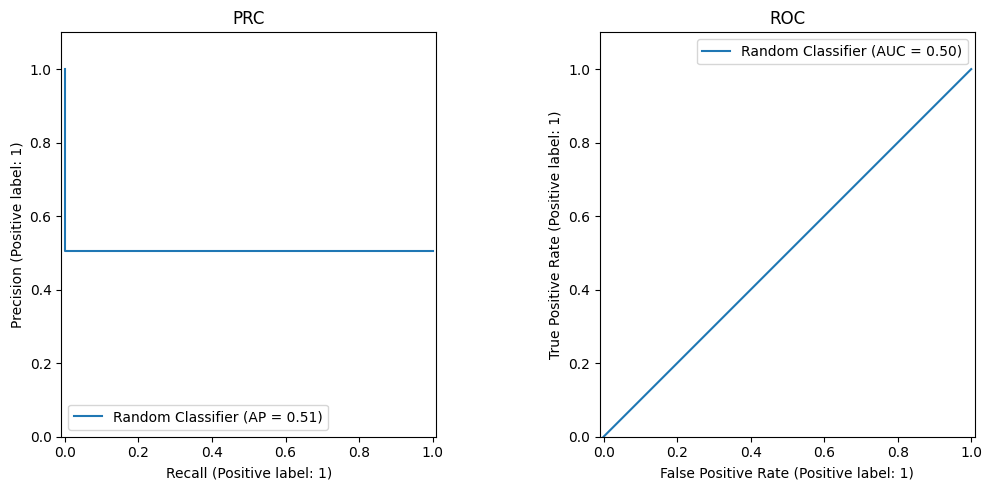

In [118]:
def depict_pr_roc(y_true, y_pred, classifier_name='Some Classifier', ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(11, 5))

    print(classifier_name, 'metrics')
    PrecisionRecallDisplay.from_predictions(y_true, y_pred, ax=ax[0], name=classifier_name)
    print('AUC-PR: %.4f' % average_precision_score(y_true, y_pred))
    ax[0].set_title("PRC")
    ax[0].set_ylim(0, 1.1)

    RocCurveDisplay.from_predictions(y_true, y_pred, ax=ax[1], name=classifier_name)
    print('AUC-ROC: %.4f' % roc_auc_score(y_true, y_pred))
    ax[1].set_title("ROC")
    ax[1].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.legend()

depict_pr_roc(y_test, y_random, 'Random Classifier')

**Support Vector Machine (Linear Kernel)**

Train a support vector machine.

Tune the regularization parameter `C` using AUC-PR as the criterion (you may use cross-validation or set aside a validation set from the training data).

In [119]:
# your code here
# ── Linear SVM: tune C using AUC-PR on a validation split ──────────────────
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

best_c_svm, best_ap_svm = None, -1
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    svm = LinearSVC(C=C, max_iter=5000, random_state=42)
    svm.fit(X_tr, y_tr)
    ap = average_precision_score(y_val, svm.decision_function(X_val))
    print(f'  C={C:7.3f}  AUC-PR={ap:.4f}')
    if ap > best_ap_svm:
        best_ap_svm, best_c_svm = ap, C

print(f'\nBest C for SVM: {best_c_svm}')

best_svm = LinearSVC(C=best_c_svm, max_iter=5000, random_state=42)
best_svm.fit(X_train, y_train)
y_svm = best_svm.decision_function(X_test)

  C=  0.001  AUC-PR=0.8218
  C=  0.010  AUC-PR=0.8216
  C=  0.100  AUC-PR=0.8215
  C=  1.000  AUC-PR=0.8215
  C= 10.000  AUC-PR=0.8215
  C=100.000  AUC-PR=0.8215

Best C for SVM: 0.001


On the test set:

* plot the ROC and PR curves,
* compute AUC-ROC and AUC-PR.

Analyze how both curves behave:

* What happens when the threshold increases? How would you interpret this?
* Are the curves monotonic? How would you explain this?

Linear SVM metrics
AUC-PR: 0.8296
AUC-ROC: 0.8474


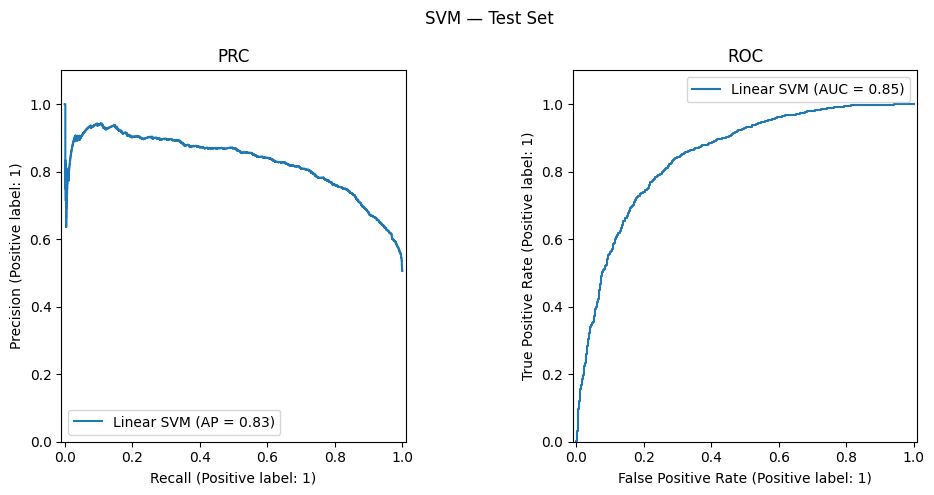

In [120]:
# SVM — plot on test set
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
depict_pr_roc(y_test, y_svm, 'Linear SVM', ax=ax)
plt.suptitle('SVM — Test Set'); plt.tight_layout(); plt.show()

Compare the AUC-ROC and AUC-PR of your model with the same metrics for the random classifier.


  C=  0.001  AUC-PR=0.8237
  C=  0.010  AUC-PR=0.8211
  C=  0.100  AUC-PR=0.8209
  C=  1.000  AUC-PR=0.8209
  C= 10.000  AUC-PR=0.8209
  C=100.000  AUC-PR=0.8209

Best C for LR: 0.001
Random Classifier metrics
AUC-PR: 0.5057
AUC-ROC: 0.5000
Linear SVM metrics
AUC-PR: 0.8296
AUC-ROC: 0.8474
Logistic Regression metrics
AUC-PR: 0.8338
AUC-ROC: 0.8453


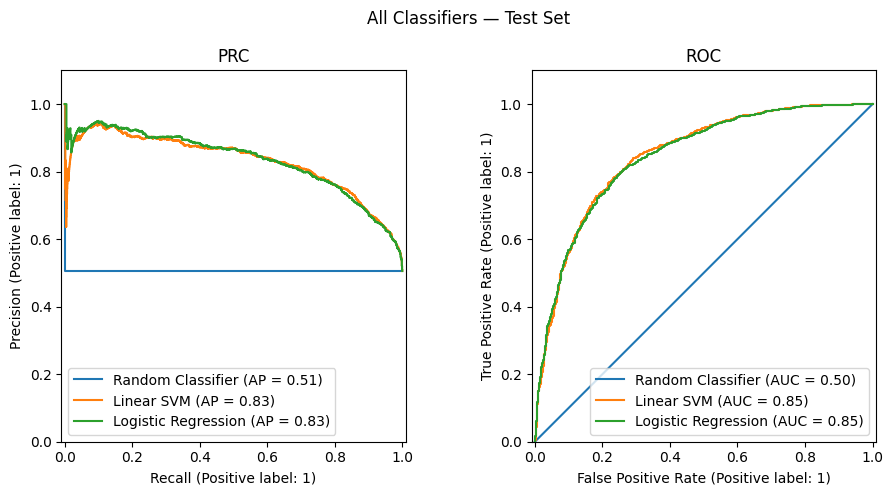


=== Summary ===
Random    AUC-PR=0.5057  AUC-ROC=0.5000
SVM       AUC-PR=0.8296  AUC-ROC=0.8474
LR        AUC-PR=0.8338  AUC-ROC=0.8453


In [121]:
# your code here
# ── Logistic Regression: tune C using AUC-PR ───────────────────────────────
best_c_lr, best_ap_lr = None, -1
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_tr, y_tr)
    ap = average_precision_score(y_val, lr.predict_proba(X_val)[:, 1])
    print(f'  C={C:7.3f}  AUC-PR={ap:.4f}')
    if ap > best_ap_lr:
        best_ap_lr, best_c_lr = ap, C

print(f'\nBest C for LR: {best_c_lr}')

best_lr = LogisticRegression(C=best_c_lr, max_iter=1000, random_state=42)
best_lr.fit(X_train, y_train)
y_lr = best_lr.predict_proba(X_test)[:, 1]

# All 3 on one figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
depict_pr_roc(y_test, y_random, 'Random Classifier',  ax=axes)
depict_pr_roc(y_test, y_svm,    'Linear SVM',          ax=axes)
depict_pr_roc(y_test, y_lr,     'Logistic Regression', ax=axes)
plt.suptitle('All Classifiers — Test Set'); plt.tight_layout(); plt.show()

print('\n=== Summary ===')
for name, pred in [('Random', y_random), ('SVM', y_svm), ('LR', y_lr)]:
    print(f'{name:8s}  AUC-PR={average_precision_score(y_test, pred):.4f}  '
          f'AUC-ROC={roc_auc_score(y_test, pred):.4f}')

**Logistic Regression**

Do the analogous task for logistic regression with L2 regularization:

* tune the hyperparameter `C` using AUC-PR,
* plot the ROC and PR curves for the test set,
* report the metrics on the test data and compare them with the results of the random classifier.

Plot the ROC and PR curves for all 3 classifiers on the same figure for the test set.

**Question:** Compare the results of LR and SVM in terms of all the computed quality criteria, and explain the differences, if any.

**Answer:** `# your answer here`

#### **Task 1.2. Visualization in SVM and LR approaches** (0.5 points)

The name “support vector machine” refers to certain “support vectors.” Essentially, these are training examples that determine the position of the separating hyperplane.

* Generate synthetic data using `make_classification` **with 2 features**, and train a support vector machine on it. Do not forget to fix the seed for reproducibility.

* Visualize the separating line, all data points, and highlight the support vectors. Templates are provided below; you may use them or write your own.

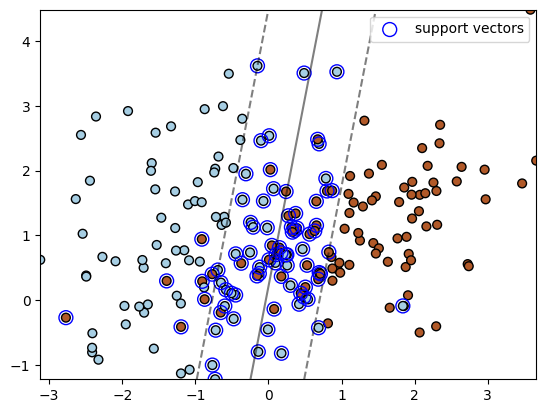

In [122]:
def plot_svm_2D(X, y, model,  plot_support=True):

    # create a grid
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Model outputs on the grid for plotting the separating line
    Z = model.decision_function(xy).reshape(XX.shape)

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Plot the sample
    plt.scatter(
        X[:,0], X[:,1],
        c=y,
        cmap=plt.cm.Paired,
        edgecolors='k',
        s=40
    )

    # Plot the support vectors
    if plot_support:
        plt.scatter(
            model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            label='support vectors',
            s=100,
            linewidth=1,
            edgecolor="blue",
            facecolors='none'
        )

    plt.legend()

from sklearn.svm import SVC

X, y = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

model = SVC(kernel='linear', C=1.0, random_state=42)
model.fit(X, y)

plot_svm_2D(X, y, model)

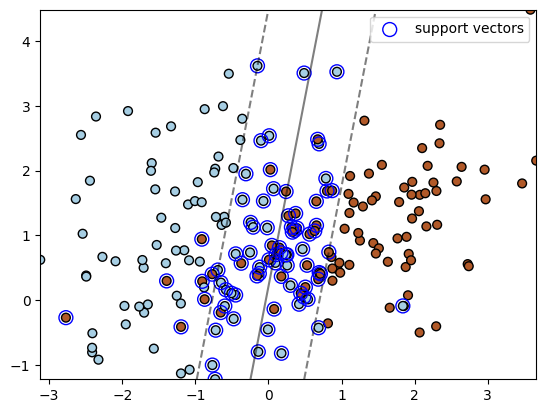

In [123]:
def plot_svm_2D(X, y, model,  plot_support=True):

    # create a grid
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Model outputs on the grid for plotting the separating line
    Z = model.decision_function(xy).reshape(XX.shape)

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Plot the sample
    plt.scatter(X[:, 0], X[:, 1],
        c=y,
        cmap=plt.cm.Paired,
        edgecolors='k',
        s=40
        
    )

    # Plot the support vectors
    if plot_support:
        plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            
            label='support vectors',
            s=100,
            linewidth=1,
            edgecolor="blue",
            facecolors='none'
        )

    plt.legend()

plot_svm_2D(X, y, model)
plt.show()


**Question:** Which objects are identified as “support” vectors?

**Answer:** `# your answer here`


Unlike support vector machines, logistic regression does not try to construct a separating hyperplane with the maximum margin. Instead, it approximates at each point in the feature space the probability of a positive outcome, $p(y=+1|x)$. Try to plot this distribution on the plane, and do not forget to mark all the objects on it.

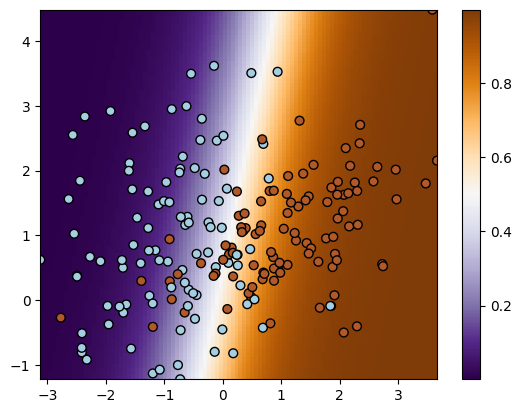

In [124]:
def plot_logreg_2D(X, y, model):
    # create a grid
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    # Model outputs on the grid for plotting the distribution
    Z = model.predict_proba(xy)[:, 1]
    Z = Z.reshape((xx.shape[0], -1)).T
    image = plt.imshow(
        Z,
        interpolation='nearest',
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        aspect='auto',
        origin='lower',
        cmap=plt.cm.PuOr_r
    )
    # Plot the sample
    plt.scatter(
        X[:,0], X[:,1],
        c=y,
        edgecolors='k',
        s=40,
        cmap=plt.cm.Paired
    )
    plt.colorbar(image)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X, y)

plot_logreg_2D(X, y, model)

**Question:** How is the region where the model is uncertain, $p(y=+1|x) = 0.5$, visualized in the figure? How can this be justified theoretically?

**Answer:** `# your answer here`


#### **Task 2. Probability Calibration** (1 point)

Let us now move on to evaluating the quality of the probabilities produced by algorithms. We begin with calibration curves.

Suppose an algorithm returns some numbers between zero and one. Do they estimate probability well?

A well-calibrated classifier should output values such that, among the samples for which it predicts a value close to $\alpha$, approximately $\alpha \cdot 100%$ actually belong to the positive class. (For example, if the classifier outputs 0.3 for some samples, then about 30% of them should belong to class 1.)

To construct a calibration curve, use the following procedure:

Generate synthetic data similarly to the very first task. Plot calibration curves on the test set for logistic regression and support vector machines (do not forget to transform its predictions to $[0,1]$).

Plot the calibration curve of a perfectly calibrated model as well (the diagonal).

Split the interval $[0, 1]$ into several small intervals of equal length.

Consider the $i$-th interval with boundaries $[a_i, b_i]$ and the predictions $p_1, p_2, \dots, p_k$ that fall into it. Let the corresponding true labels be $y_1, y_2, \dots, y_k$. If the algorithm outputs correct probabilities, then among these true labels there should be approximately $(a_i + b_i)/2$ ones. In other words, if we draw a curve where the x-axis represents the interval centers and the y-axis represents the fractions of positive labels in those intervals, then the curve should lie along the diagonal.

Below is a function that is supposed to plot such curves. It contains two mistakes — find and correct them.


In [125]:
def plot_calibration_curve(y_test, preds, label='model'):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((l + r) / 2)        # FIX 1: was (l - r)/2
        mask = (preds >= l) & (preds < r)
        if mask.sum() == 0:
            bin_real_ratios.append(np.nan)
        else:
            bin_real_ratios.append(np.mean(y_test[mask] == 1))  # FIX 2: was np.min
    plt.plot(bin_middle_points, bin_real_ratios, marker='o', label=label)
    plt.ylim([-0.05, 1.05])
    plt.grid()

Generate synthetic data in the same way as in the very first task. Plot calibration curves on the test set for logistic regression and support vector machines (do not forget to transform the SVM predictions to $[0,1]$). Also plot the calibration curve of a perfectly calibrated model (the diagonal).

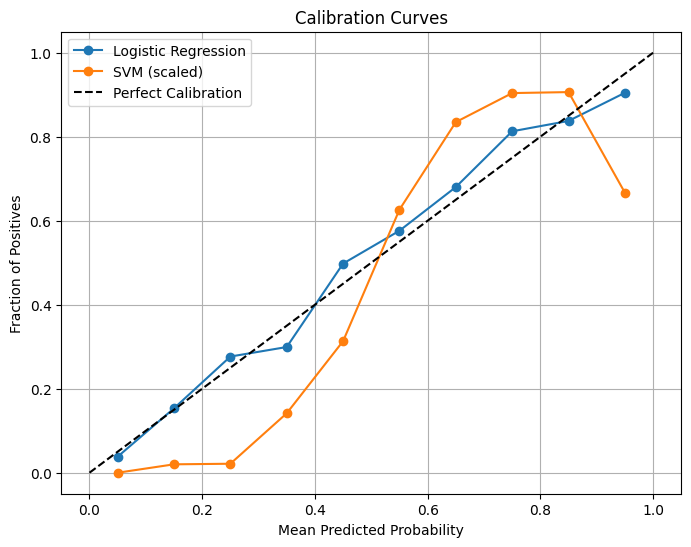

In [126]:
# your code
# Generate synthetic data same as Task 1.1
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_lr = lr.predict_proba(X_test)[:, 1]

# Train SVM and scale predictions to [0, 1]
svm = LinearSVC(random_state=42, max_iter=5000)
svm.fit(X_train, y_train)
y_svm = svm.decision_function(X_test)
y_svm_scaled = (y_svm - y_svm.min()) / (y_svm.max() - y_svm.min())

# Plot calibration curves
plt.figure(figsize=(8, 6))

plot_calibration_curve(y_test, y_lr, label='Logistic Regression')
plot_calibration_curve(y_test, y_svm_scaled, label='SVM (scaled)')

# Perfect calibration diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves')
plt.legend()
plt.grid()
plt.show()

**Question:** Are the curves for SVM and logistic regression well calibrated? Think about how this follows from the shape of the curve.

**Answer:** `# your answer here`

Among the formal ways to verify this are the familiar LogLoss, which directly evaluates probabilities,
$$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0, 1}}\log p_k[y_i = k]$$
as well as the Brier Score, which measures the deviation between the predicted probability and the true target value.
$$\text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2$$

In [127]:
from sklearn.metrics import log_loss, brier_score_loss

# LogLoss and Brier Score for Logistic Regression
print('=== Logistic Regression ===')
print(f'LogLoss:     {log_loss(y_test, y_lr):.4f}')
print(f'Brier Score: {brier_score_loss(y_test, y_lr):.4f}')

# LogLoss and Brier Score for SVM (scaled)
print('\n=== SVM (scaled) ===')
print(f'LogLoss:     {log_loss(y_test, y_svm_scaled):.4f}')
print(f'Brier Score: {brier_score_loss(y_test, y_svm_scaled):.4f}')

=== Logistic Regression ===
LogLoss:     0.4859
Brier Score: 0.1586

=== SVM (scaled) ===
LogLoss:     0.5546
Brier Score: 0.1845


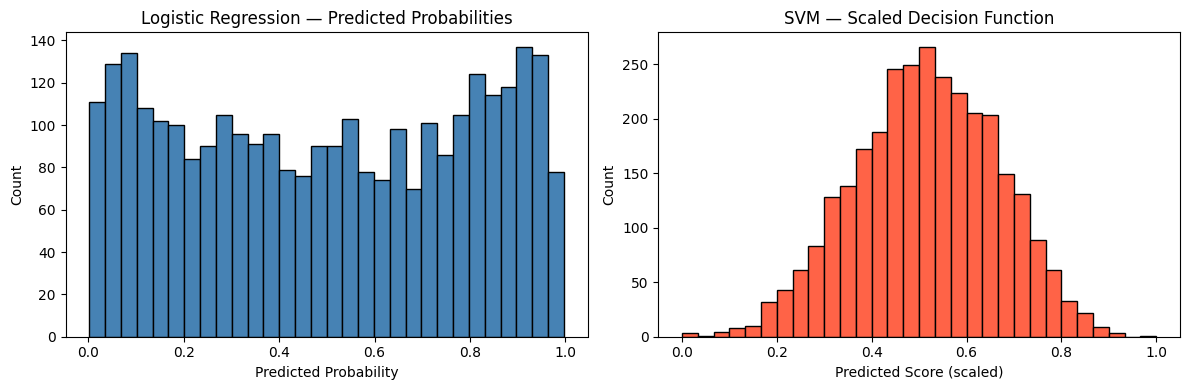

In [128]:
# Study the distribution of classifier outputs using histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_lr, bins=30, color='steelblue', edgecolor='k')
axes[0].set_title('Logistic Regression — Predicted Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')

axes[1].hist(y_svm_scaled, bins=30, color='tomato', edgecolor='k')
axes[1].set_title('SVM — Scaled Decision Function')
axes[1].set_xlabel('Predicted Score (scaled)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Look at these metrics as well and draw a conclusion.

Study the distribution of classifier outputs using histograms.

=== Logistic Regression ===
LogLoss:     0.4859
Brier Score: 0.1586

=== SVM (scaled) ===
LogLoss:     0.5546
Brier Score: 0.1845


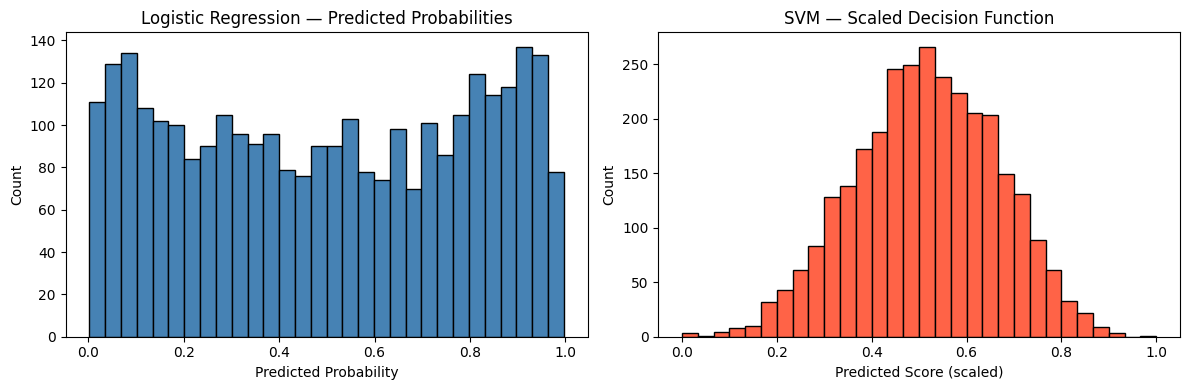

In [129]:
# your code here
# Compute metrics
from sklearn.metrics import log_loss, brier_score_loss

print('=== Logistic Regression ===')
print(f'LogLoss:     {log_loss(y_test, y_lr):.4f}')
print(f'Brier Score: {brier_score_loss(y_test, y_lr):.4f}')

print('\n=== SVM (scaled) ===')
print(f'LogLoss:     {log_loss(y_test, y_svm_scaled):.4f}')
print(f'Brier Score: {brier_score_loss(y_test, y_svm_scaled):.4f}')

# Histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_lr, bins=30, color='steelblue', edgecolor='k')
axes[0].set_title('Logistic Regression — Predicted Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')

axes[1].hist(y_svm_scaled, bins=30, color='tomato', edgecolor='k')
axes[1].set_title('SVM — Scaled Decision Function')
axes[1].set_xlabel('Predicted Score (scaled)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Question:** How do they differ? How can you explain this?

**Answer:** `# your answer here`

Use `CalibratedClassifierCV` from `sklearn` to calibrate the probabilities of the support vector machine on the training set, and then use it to generate predictions for the test set.

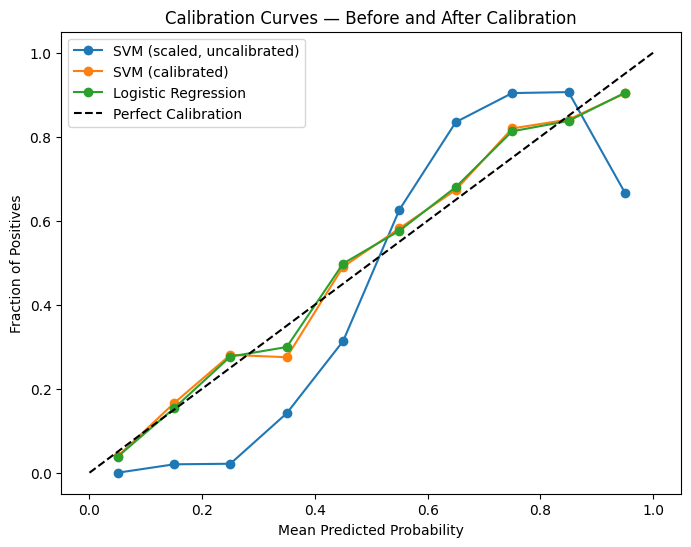

=== Before Calibration (SVM scaled) ===
LogLoss:     0.5546
Brier Score: 0.1845

=== After Calibration (SVM calibrated) ===
LogLoss:     0.4862
Brier Score: 0.1587


In [130]:
# your code here
from sklearn.calibration import CalibratedClassifierCV

# Calibrate SVM using CalibratedClassifierCV
calibrated_svm = CalibratedClassifierCV(
    LinearSVC(random_state=42, max_iter=5000),
    cv=5,
    method='sigmoid'  # Platt scaling
)
calibrated_svm.fit(X_train, y_train)

# Generate predictions for the test set
y_svm_calibrated = calibrated_svm.predict_proba(X_test)[:, 1]

# Plot calibration curves to compare
plt.figure(figsize=(8, 6))

plot_calibration_curve(y_test, y_svm_scaled,     label='SVM (scaled, uncalibrated)')
plot_calibration_curve(y_test, y_svm_calibrated, label='SVM (calibrated)')
plot_calibration_curve(y_test, y_lr,             label='Logistic Regression')

plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves — Before and After Calibration')
plt.legend()
plt.grid()
plt.show()

# Compare metrics
print('=== Before Calibration (SVM scaled) ===')
print(f'LogLoss:     {log_loss(y_test, y_svm_scaled):.4f}')
print(f'Brier Score: {brier_score_loss(y_test, y_svm_scaled):.4f}')

print('\n=== After Calibration (SVM calibrated) ===')
print(f'LogLoss:     {log_loss(y_test, y_svm_calibrated):.4f}')
print(f'Brier Score: {brier_score_loss(y_test, y_svm_calibrated):.4f}')

**Question:** Did the calibration curve and calibration quality improve?

**Answer:** `# your answer here`


##### **Bonus: Author’s solution** (0.5 points)

Implement your own probability calibration function using any known approach. Briefly describe your approach and demonstrate the results.

Keywords for inspiration: `Platt`, `Isotonic`.

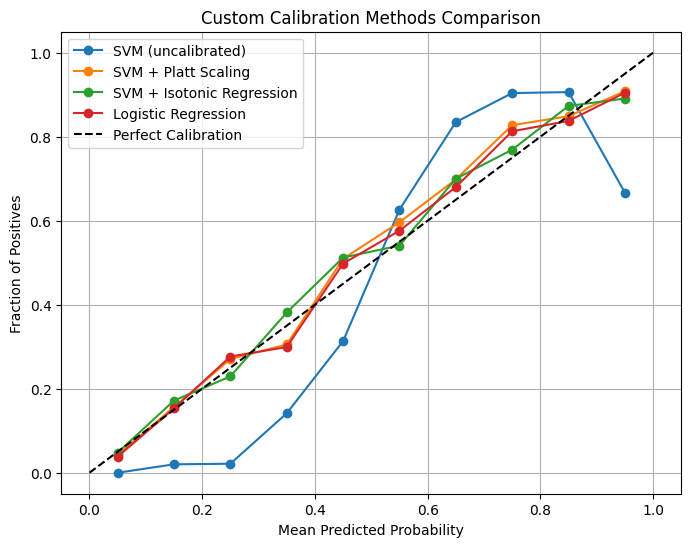

Model                             LogLoss  Brier Score
-------------------------------------------------------
SVM (uncalibrated)                 0.5546       0.1845
SVM + Platt Scaling                0.4881       0.1594
SVM + Isotonic Regression          0.5101       0.1600
Logistic Regression                0.4859       0.1586


In [131]:
# Bonus: Custom Probability Calibration using Platt Scaling
from scipy.special import expit  # sigmoid function
from scipy.optimize import minimize

class PlattScaling:
    """
    Platt Scaling calibration.
    Fits a sigmoid function f(s) = 1 / (1 + exp(A*s + B))
    on top of raw classifier scores to produce calibrated probabilities.
    """
    def __init__(self):
        self.A = None
        self.B = None

    def fit(self, scores, y):
        # Optimize A and B using log-loss minimization
        def log_loss_func(params):
            A, B = params
            probs = expit(A * scores + B)
            probs = np.clip(probs, 1e-10, 1 - 1e-10)
            return -np.mean(y * np.log(probs) + (1 - y) * np.log(1 - probs))

        result = minimize(log_loss_func, x0=[1.0, 0.0], method='Nelder-Mead')
        self.A, self.B = result.x
        return self

    def predict_proba(self, scores):
        return expit(self.A * scores + self.B)


class IsotonicCalibration:
    """
    Isotonic Regression calibration.
    Fits a non-decreasing step function on raw scores.
    More flexible than Platt scaling but needs more data.
    """
    def __init__(self):
        self.iso = None

    def fit(self, scores, y):
        from sklearn.isotonic import IsotonicRegression
        self.iso = IsotonicRegression(out_of_bounds='clip')
        self.iso.fit(scores, y)
        return self

    def predict_proba(self, scores):
        return self.iso.predict(scores)


# Split training set into fit and calibration sets
X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

# Train SVM on fit set
svm_raw = LinearSVC(random_state=42, max_iter=5000)
svm_raw.fit(X_fit, y_fit)

# Get raw scores
scores_calib = svm_raw.decision_function(X_calib)
scores_test  = svm_raw.decision_function(X_test)

# Fit Platt Scaling
platt = PlattScaling()
platt.fit(scores_calib, y_calib)
y_platt = platt.predict_proba(scores_test)

# Fit Isotonic Regression
isotonic = IsotonicCalibration()
isotonic.fit(scores_calib, y_calib)
y_isotonic = isotonic.predict_proba(scores_test)

# Plot calibration curves
plt.figure(figsize=(8, 6))
plot_calibration_curve(y_test, y_svm_scaled,  label='SVM (uncalibrated)')
plot_calibration_curve(y_test, y_platt,       label='SVM + Platt Scaling')
plot_calibration_curve(y_test, y_isotonic,    label='SVM + Isotonic Regression')
plot_calibration_curve(y_test, y_lr,          label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Custom Calibration Methods Comparison')
plt.legend()
plt.grid()
plt.show()

# Compare metrics
print(f'{"Model":<30} {"LogLoss":>10} {"Brier Score":>12}')
print('-' * 55)
print(f'{"SVM (uncalibrated)":<30} {log_loss(y_test, y_svm_scaled):>10.4f} {brier_score_loss(y_test, y_svm_scaled):>12.4f}')
print(f'{"SVM + Platt Scaling":<30} {log_loss(y_test, y_platt):>10.4f} {brier_score_loss(y_test, y_platt):>12.4f}')
print(f'{"SVM + Isotonic Regression":<30} {log_loss(y_test, y_isotonic):>10.4f} {brier_score_loss(y_test, y_isotonic):>12.4f}')
print(f'{"Logistic Regression":<30} {log_loss(y_test, y_lr):>10.4f} {brier_score_loss(y_test, y_lr):>12.4f}')

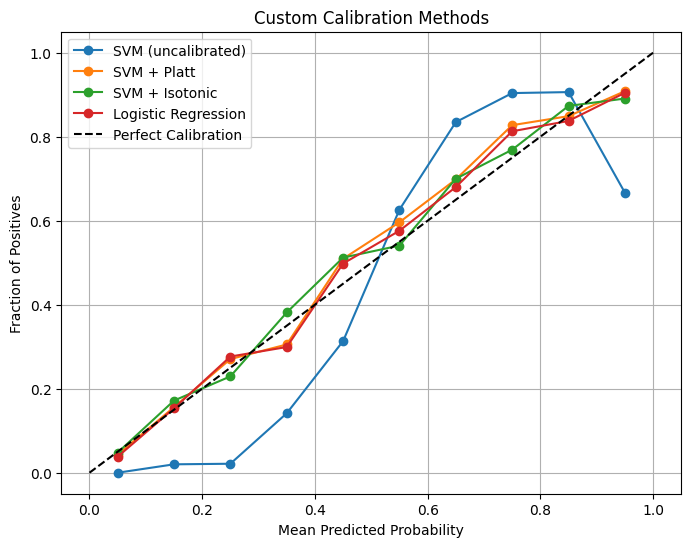

Model                             LogLoss      Brier
----------------------------------------------------
SVM (uncalibrated)                 0.5546     0.1845
SVM + Platt                        0.4881     0.1594
SVM + Isotonic                     0.5101     0.1600
Logistic Regression                0.4859     0.1586


In [132]:
from scipy.special import expit
from scipy.optimize import minimize
from sklearn.isotonic import IsotonicRegression

class PlattScaling:
    def __init__(self):
        self.A = self.B = None

    def fit(self, scores, y):
        def nll(params):
            p = np.clip(expit(params[0]*scores + params[1]), 1e-10, 1-1e-10)
            return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))
        self.A, self.B = minimize(nll, [1.0, 0.0], method='Nelder-Mead').x
        return self

    def predict_proba(self, scores):
        return expit(self.A * scores + self.B)


class IsotonicCalibration:
    def __init__(self):
        self.iso = IsotonicRegression(out_of_bounds='clip')

    def fit(self, scores, y):
        self.iso.fit(scores, y)
        return self

    def predict_proba(self, scores):
        return self.iso.predict(scores)


# Split, train, get scores
X_fit, X_calib, y_fit, y_calib = train_test_split(X_train, y_train, test_size=0.3, random_state=42)
svm_raw = LinearSVC(random_state=42, max_iter=5000).fit(X_fit, y_fit)
scores_calib = svm_raw.decision_function(X_calib)
scores_test  = svm_raw.decision_function(X_test)

# Fit calibrators
y_platt    = PlattScaling().fit(scores_calib, y_calib).predict_proba(scores_test)
y_isotonic = IsotonicCalibration().fit(scores_calib, y_calib).predict_proba(scores_test)

# Plot
plt.figure(figsize=(8, 6))
plot_calibration_curve(y_test, y_svm_scaled, label='SVM (uncalibrated)')
plot_calibration_curve(y_test, y_platt,      label='SVM + Platt')
plot_calibration_curve(y_test, y_isotonic,   label='SVM + Isotonic')
plot_calibration_curve(y_test, y_lr,         label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Custom Calibration Methods')
plt.legend(); plt.grid(); plt.show()

# Metrics
print(f'{"Model":<30} {"LogLoss":>10} {"Brier":>10}')
print('-' * 52)
for name, pred in [('SVM (uncalibrated)', y_svm_scaled),
                   ('SVM + Platt',        y_platt),
                   ('SVM + Isotonic',     y_isotonic),
                   ('Logistic Regression',y_lr)]:
    print(f'{name:<30} {log_loss(y_test, pred):>10.4f} {brier_score_loss(y_test, pred):>10.4f}')

# Part 2. Processing Categorical Variables (4 points + 1.5 bonus)

As we know, encoding a categorical variable as a list of numbers (for example, 1, 2, 3, ..., n) is a bad idea, because this imposes an ordering on its values that usually has no meaning.

In this part, we will consider two main approaches to handling categorical values:

* One-hot encoding
* Counters (CTR, mean-target encoding, etc.) — each categorical feature is replaced by the mean value of the target variable over all objects that have the same value of this feature.

Let us begin with one-hot encoding. Suppose our categorical feature $f_j(x)$ takes values from the set $C = {c_1, \dots, c_m}$. We replace it with $m$ binary features $b_1(x), \dots, b_m(x)$, each of which is an indicator of one of the possible category values:
$$
b_i(x) = [f_j(x) = c_i]
$$

#### **Data preparation**

*(a priceless step)* 

Let us examine the [bike buyers dataset](https://www.kaggle.com/datasets/heeraldedhia/bike-buyers/): customer features are given, and the task is to predict whether the customer will buy a bicycle.

Replace missing values in categorical variables with a new category (`'undefined'`).

Split the features into two tables: categorical features and numerical features.

In [133]:
# Read the dataset
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/christopherpagaduan/dataset-bike/bike_buyers.csv')

# Replace missing values in categorical variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
df[cat_cols] = df[cat_cols].fillna('undefined')

# Separate X and y
y = (df['Purchased Bike'] == 'Yes').astype(int)
X = df.drop(columns=['ID', 'Purchased Bike'])

# Split into categorical and numerical features
X_numerical  = X.select_dtypes(exclude='object')
X_categorical = X.select_dtypes(include='object')

print('X_numerical shape:',  X_numerical.shape)
print('X_categorical shape:', X_categorical.shape)
print('y shape:', y.shape)

X_numerical shape: (1000, 4)
X_categorical shape: (1000, 7)
y shape: (1000,)


At first, we will work only with the categorical features.

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X_categorical, y, test_size=0.25, random_state=777, stratify=y
)

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_categorical, y, test_size=0.25, random_state=777, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:',  X_test.shape)

X_train shape: (750, 7)
X_test shape: (250, 7)


#### **Task 3. OrdinalEncoder** (0.5 points)

Encode the categorical features using `OrdinalEncoder`. Compute the model quality (in this task we will use **`AUC-PR`**) when applying logistic regression. Measure the time required to train the model, including the feature encoding step.

In [136]:
# your code here
import time
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

# Start timer
t0 = time.time()

# Encode categorical features using OrdinalEncoder
enc_ord = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_ord = enc_ord.fit_transform(X_train)
X_test_ord  = enc_ord.transform(X_test)

# Train Logistic Regression
lr_ord = LogisticRegression(max_iter=1000, random_state=42)
lr_ord.fit(X_train_ord, y_train)

# Stop timer
t_ord = time.time() - t0

# Compute AUC-PR
y_pred_ord = lr_ord.predict_proba(X_test_ord)[:, 1]
auc_pr_ord = average_precision_score(y_test, y_pred_ord)

print(f'Encoding + Training time: {t_ord:.4f} seconds')
print(f'AUC-PR (OrdinalEncoder): {auc_pr_ord:.4f}')

Encoding + Training time: 0.0132 seconds
AUC-PR (OrdinalEncoder): 0.5887


#### **Task 4. One-Hot Encoding** (0.5 points)

Encode all categorical features using one-hot encoding. Train logistic regression and see how the model quality changes (compared with what it was before encoding). Measure the time required for encoding the categorical features and training the model.

As we can see, one-hot encoding can greatly increase the number of features. This affects the amount of memory required, especially if some feature has a large number of distinct values.

In [137]:
# your code here
from sklearn.preprocessing import OneHotEncoder

t0 = time.time()

# Encode categorical features using OneHotEncoder
enc_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = enc_ohe.fit_transform(X_train)
X_test_ohe  = enc_ohe.transform(X_test)

# Train Logistic Regression
lr_ohe = LogisticRegression(max_iter=1000, random_state=42)
lr_ohe.fit(X_train_ohe, y_train)

t_ohe = time.time() - t0

# Compute AUC-PR
y_pred_ohe = lr_ohe.predict_proba(X_test_ohe)[:, 1]
auc_pr_ohe = average_precision_score(y_test, y_pred_ohe)

print(f'Number of features after OHE: {X_train_ohe.shape[1]}')
print(f'Encoding + Training time: {t_ohe:.4f} seconds')
print(f'AUC-PR (OneHotEncoder):  {auc_pr_ohe:.4f}')

# Compare with OrdinalEncoder
print(f'\n=== Comparison ===')
print(f'OrdinalEncoder  AUC-PR: {auc_pr_ord:.4f}  time: {t_ord:.4f}s')
print(f'OneHotEncoder   AUC-PR: {auc_pr_ohe:.4f}  time: {t_ohe:.4f}s')

Number of features after OHE: 27
Encoding + Training time: 0.0244 seconds
AUC-PR (OneHotEncoder):  0.6663

=== Comparison ===
OrdinalEncoder  AUC-PR: 0.5887  time: 0.0132s
OneHotEncoder   AUC-PR: 0.6663  time: 0.0244s


#### **Task 5. Mean-target Encoding** (1 point)

> The problem of feature-space explosion can be avoided with another method of encoding categorical features — mean-target encoding (for simplicity, we will refer to it as **counters**). Let us compare the effectiveness of the methods within our marketing task.

> The main idea is that what matters is not the categories themselves, but the target values of the objects belonging to those categories. We replace each categorical feature with the mean value of the target variable over all objects having the same category value:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$

Encode the categorical variables using counters exactly as described above, without any additional tricks. Train logistic regression and evaluate the model quality on the test set.

Compare the training time with the previous experiments, including the encoding step.

In [138]:
# your code
t0 = time.time()

# Mean-target encoding
X_train_mte = X_train.copy().reset_index(drop=True)
X_test_mte  = X_test.copy().reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

for col in X_train.columns:
    # Compute mean target per category on training set only
    mapping = y_train_reset.groupby(X_train_mte[col]).mean()
    
    # Apply mapping to train and test
    X_train_mte[col] = X_train_mte[col].map(mapping)
    X_test_mte[col]  = X_test_mte[col].map(mapping).fillna(y_train_reset.mean())

# Train Logistic Regression
lr_mte = LogisticRegression(max_iter=1000, random_state=42)
lr_mte.fit(X_train_mte, y_train)

t_mte = time.time() - t0

# Compute AUC-PR
y_pred_mte = lr_mte.predict_proba(X_test_mte)[:, 1]
auc_pr_mte = average_precision_score(y_test, y_pred_mte)

print(f'Encoding + Training time: {t_mte:.4f} seconds')
print(f'AUC-PR (Mean-Target Encoding): {auc_pr_mte:.4f}')

# Compare all methods
print(f'\n=== Comparison ===')
print(f'{"Method":<25} {"AUC-PR":>10} {"Time":>10}')
print('-' * 48)
print(f'{"OrdinalEncoder":<25} {auc_pr_ord:>10.4f} {t_ord:>9.4f}s')
print(f'{"OneHotEncoder":<25} {auc_pr_ohe:>10.4f} {t_ohe:>9.4f}s')
print(f'{"MeanTargetEncoding":<25} {auc_pr_mte:>10.4f} {t_mte:>9.4f}s')

Encoding + Training time: 0.0299 seconds
AUC-PR (Mean-Target Encoding): 0.6575

=== Comparison ===
Method                        AUC-PR       Time
------------------------------------------------
OrdinalEncoder                0.5887    0.0132s
OneHotEncoder                 0.6663    0.0244s
MeanTargetEncoding            0.6575    0.0299s


##### **Bonus: Efficient implementation** (1 point)

From this point on, implement the computation of counters using a transformer inherited from `BaseEstimator` and `TransformerMixin` from `sklearn.base`.

Note that:

* all computations must be vectorized,
* the transformer must not modify the input dataset in place,
* all required statistics must be computed only on the training set inside the `fit` method.

Your transformer should accept, at initialization, a list of categorical features and should transform only those features.

In [139]:
# your code
from sklearn.base import BaseEstimator, TransformerMixin

class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    """
    Mean-target encoder as a proper sklearn transformer.
    - Vectorized computations
    - Does not modify input in place
    - Statistics computed only on training set in fit()
    - Accepts a list of categorical features at initialization
    """

    def __init__(self, cat_features=None):
        self.cat_features = cat_features
        self.mappings_    = {}
        self.global_mean_ = None

    def fit(self, X, y):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        y = pd.Series(y)    if not isinstance(y, pd.Series)    else y

        # Compute global mean as fallback for unseen categories
        self.global_mean_ = y.mean()

        # Compute mean target per category for each feature
        features = self.cat_features if self.cat_features else X.columns.tolist()
        for col in features:
            self.mappings_[col] = y.groupby(X[col].values).mean()

        return self

    def transform(self, X):
        # Copy to avoid modifying input in place
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()

        for col, mapping in self.mappings_.items():
            X[col] = X[col].map(mapping).fillna(self.global_mean_)

        return X


# ── Test the transformer ───────────────────────────────────────────────────
t0 = time.time()

cat_features = X_train.columns.tolist()

mte = MeanTargetEncoder(cat_features=cat_features)
X_train_mte2 = mte.fit_transform(X_train, y_train)
X_test_mte2  = mte.transform(X_test)

lr_mte2 = LogisticRegression(max_iter=1000, random_state=42)
lr_mte2.fit(X_train_mte2, y_train)

t_mte2 = time.time() - t0

y_pred_mte2 = lr_mte2.predict_proba(X_test_mte2)[:, 1]
auc_pr_mte2 = average_precision_score(y_test, y_pred_mte2)

print(f'Encoding + Training time: {t_mte2:.4f} seconds')
print(f'AUC-PR (MeanTargetEncoder transformer): {auc_pr_mte2:.4f}')

# Compare with previous results
print(f'\n=== Comparison ===')
print(f'{"Method":<35} {"AUC-PR":>10} {"Time":>10}')
print('-' * 58)
print(f'{"OrdinalEncoder":<35} {auc_pr_ord:>10.4f} {t_ord:>9.4f}s')
print(f'{"OneHotEncoder":<35} {auc_pr_ohe:>10.4f} {t_ohe:>9.4f}s')
print(f'{"MeanTargetEncoding (manual)":<35} {auc_pr_mte:>10.4f} {t_mte:>9.4f}s')
print(f'{"MeanTargetEncoding (transformer)":<35} {auc_pr_mte2:>10.4f} {t_mte2:>9.4f}s')

Encoding + Training time: 0.0267 seconds
AUC-PR (MeanTargetEncoder transformer): 0.6575

=== Comparison ===
Method                                  AUC-PR       Time
----------------------------------------------------------
OrdinalEncoder                          0.5887    0.0132s
OneHotEncoder                           0.6663    0.0244s
MeanTargetEncoding (manual)             0.6575    0.0299s
MeanTargetEncoding (transformer)        0.6575    0.0267s


In [140]:
from sklearn.base import BaseEstimator, TransformerMixin

class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    """
    Mean-target encoder following all requirements:
    - Fully vectorized using groupby + map
    - Does NOT modify input in place (uses .copy())
    - All statistics computed ONLY in fit() on training set
    - Accepts list of categorical features at initialization
    """

    def __init__(self, cat_features=None):
        self.cat_features = cat_features

    def fit(self, X, y):
        # Rule 3: compute ALL statistics only here on training data
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        y = np.array(y)

        features = self.cat_features if self.cat_features else X.columns.tolist()

        # Rule 1: vectorized — groupby computes all stats at once
        self.global_mean_ = y.mean()
        self.mappings_ = {
            col: pd.Series(y).groupby(X[col].values).mean()
            for col in features
        }
        return self

    def transform(self, X):
        # Rule 2: copy first — never modify in place
        X_out = pd.DataFrame(X).copy() if not isinstance(X, pd.DataFrame) else X.copy()

        # Rule 1: vectorized map for all features at once
        for col, mapping in self.mappings_.items():
            X_out[col] = X_out[col].map(mapping).fillna(self.global_mean_)

        return X_out.values  # return numpy array


# ── Test the transformer ───────────────────────────────────────────────────
t0 = time.time()

mte = MeanTargetEncoder(cat_features=X_train.columns.tolist())
X_train_mte2 = mte.fit_transform(X_train, y_train)
X_test_mte2  = mte.transform(X_test)

lr_mte2 = LogisticRegression(max_iter=1000, random_state=42)
lr_mte2.fit(X_train_mte2, y_train)

t_mte2 = time.time() - t0

y_pred_mte2 = lr_mte2.predict_proba(X_test_mte2)[:, 1]
auc_pr_mte2 = average_precision_score(y_test, y_pred_mte2)

print(f'Encoding + Training time: {t_mte2:.4f} seconds')
print(f'AUC-PR (MeanTargetEncoder transformer): {auc_pr_mte2:.4f}')

# Compare all methods
print(f'\n=== Comparison ===')
print(f'{"Method":<35} {"AUC-PR":>10} {"Time":>10}')
print('-' * 58)
print(f'{"OrdinalEncoder":<35} {auc_pr_ord:>10.4f} {t_ord:>9.4f}s')
print(f'{"OneHotEncoder":<35} {auc_pr_ohe:>10.4f} {t_ohe:>9.4f}s')
print(f'{"MeanTargetEncoding (manual)":<35} {auc_pr_mte:>10.4f} {t_mte:>9.4f}s')
print(f'{"MeanTargetEncoding (transformer)":<35} {auc_pr_mte2:>10.4f} {t_mte2:>9.4f}s')

Encoding + Training time: 0.0267 seconds
AUC-PR (MeanTargetEncoder transformer): 0.6575

=== Comparison ===
Method                                  AUC-PR       Time
----------------------------------------------------------
OrdinalEncoder                          0.5887    0.0132s
OneHotEncoder                           0.6663    0.0244s
MeanTargetEncoding (manual)             0.6575    0.0299s
MeanTargetEncoding (transformer)        0.6575    0.0267s


**Question:** Draw conclusions. Did adding noise help? Why?

**Answer:** `# your answer here`

##### **Bonus: another approach** (0.5 points)

Compute correct counters using the first or second method described above, and do not forget to add noise as well.

In [141]:
# your code
class MeanTargetEncoderWithNoise(BaseEstimator, TransformerMixin):
    """
    Mean-target encoder with Gaussian noise added during transform.
    - Fully vectorized
    - Does NOT modify input in place
    - All statistics computed ONLY in fit() on training set
    - Noise added only during training transform to prevent overfitting
    """

    def __init__(self, cat_features=None, noise_std=0.01, random_state=42):
        self.cat_features = cat_features
        self.noise_std    = noise_std
        self.random_state = random_state

    def fit(self, X, y):
        # Compute all statistics only on training data
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        y = np.array(y)

        features = self.cat_features if self.cat_features else X.columns.tolist()

        # Vectorized groupby
        self.global_mean_ = y.mean()
        self.mappings_ = {
            col: pd.Series(y).groupby(X[col].values).mean()
            for col in features
        }
        return self

    def transform(self, X, add_noise=False):
        # Copy first — never modify in place
        X_out = pd.DataFrame(X).copy() if not isinstance(X, pd.DataFrame) else X.copy()

        np.random.seed(self.random_state)
        for col, mapping in self.mappings_.items():
            # Vectorized map
            X_out[col] = X_out[col].map(mapping).fillna(self.global_mean_)

            # Add Gaussian noise only during training to reduce overfitting
            if add_noise:
                noise = np.random.normal(0, self.noise_std, size=X_out[col].shape)
                X_out[col] = X_out[col] + noise
                # Clip to valid probability range [0, 1]
                X_out[col] = X_out[col].clip(0, 1)

        return X_out.values


# ── Test with and without noise ────────────────────────────────────────────
results = {}

for noise_std in [0.0, 0.001, 0.005, 0.01, 0.05]:
    t0 = time.time()

    mte_noise = MeanTargetEncoderWithNoise(
        cat_features=X_train.columns.tolist(),
        noise_std=noise_std,
        random_state=42
    )

    # Add noise only on training set
    X_train_noise = mte_noise.fit_transform(X_train, y_train)
    X_train_noise = mte_noise.transform(X_train, add_noise=(noise_std > 0))
    X_test_noise  = mte_noise.transform(X_test,  add_noise=False)

    lr_noise = LogisticRegression(max_iter=1000, random_state=42)
    lr_noise.fit(X_train_noise, y_train)

    t_noise = time.time() - t0

    y_pred_noise = lr_noise.predict_proba(X_test_noise)[:, 1]
    auc_pr_noise = average_precision_score(y_test, y_pred_noise)
    results[noise_std] = {'auc_pr': auc_pr_noise, 'time': t_noise}

    print(f'noise_std={noise_std:.3f}  AUC-PR={auc_pr_noise:.4f}  time={t_noise:.4f}s')

# Summary
print(f'\n=== Comparison ===')
print(f'{"Method":<35} {"AUC-PR":>10} {"Time":>10}')
print('-' * 58)
print(f'{"OrdinalEncoder":<35} {auc_pr_ord:>10.4f} {t_ord:>9.4f}s')
print(f'{"OneHotEncoder":<35} {auc_pr_ohe:>10.4f} {t_ohe:>9.4f}s')
print(f'{"MeanTargetEncoding (no noise)":<35} {auc_pr_mte2:>10.4f} {t_mte2:>9.4f}s')
for noise_std, res in results.items():
    print(f'{"MeanTargetEncoding noise="+str(noise_std):<35} {res["auc_pr"]:>10.4f} {res["time"]:>9.4f}s')

noise_std=0.000  AUC-PR=0.6575  time=0.0300s
noise_std=0.001  AUC-PR=0.6563  time=0.0374s
noise_std=0.005  AUC-PR=0.6561  time=0.0363s
noise_std=0.010  AUC-PR=0.6579  time=0.0376s
noise_std=0.050  AUC-PR=0.6679  time=0.0359s

=== Comparison ===
Method                                  AUC-PR       Time
----------------------------------------------------------
OrdinalEncoder                          0.5887    0.0132s
OneHotEncoder                           0.6663    0.0244s
MeanTargetEncoding (no noise)           0.6575    0.0267s
MeanTargetEncoding noise=0.0            0.6575    0.0300s
MeanTargetEncoding noise=0.001          0.6563    0.0374s
MeanTargetEncoding noise=0.005          0.6561    0.0363s
MeanTargetEncoding noise=0.01           0.6579    0.0376s
MeanTargetEncoding noise=0.05           0.6679    0.0359s


#### **Task 7. Smoothing the counters** (1 point)

Now let us answer the following question: what happens if a certain category appears only a few times in the sample? This is why smoothing of counters is used. For example, in practice, good results are often obtained by smoothing with the global mean over the whole sample:
$$ g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1] + C \times \text{global\_mean}}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)] + C} $$

where $\text{global\_mean}$ is the proportion of positive-class objects in the sample, and $C$ is a parameter controlling the degree of smoothing (you may use 10 or tune a separate value for each feature). The idea is that we “dilute” the category mean with the global mean. The larger the number of objects in the category, the weaker this effect becomes.

Instead of the target mean, any other value between 0 and 1 can be used for smoothing (this parameter is sometimes called the $prior$). One can even create several features with different values of this parameter. In practice, in binary classification tasks, even negative values may sometimes be useful.

Add the smoothing described above and repeat the experiments. Tune $C$ so that the quality is better than when using One-Hot Encoding.

In [142]:
# your code here

C=   1  AUC-PR=0.6619  time=0.0287s
C=   5  AUC-PR=0.6706  time=0.0255s
C=  10  AUC-PR=0.6713  time=0.0271s
C=  20  AUC-PR=0.6694  time=0.0243s
C=  50  AUC-PR=0.6647  time=0.0257s
C= 100  AUC-PR=0.6562  time=0.0257s
C= 200  AUC-PR=0.6385  time=0.0226s

Best C: 10  AUC-PR: 0.6713

=== Final Comparison ===
Method                                       AUC-PR       Time
---------------------------------------------------------------
OrdinalEncoder                               0.5887    0.0132s
OneHotEncoder                                0.6663    0.0244s
MeanTargetEncoding (no smoothing)            0.6575    0.0267s
SmoothedMeanTargetEncoding (best C=10)       0.6713


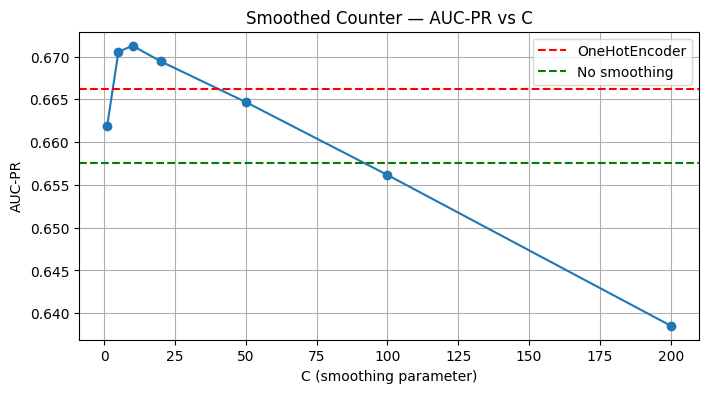

In [143]:
class SmoothedMeanTargetEncoder(BaseEstimator, TransformerMixin):
    """
    Smoothed Mean-Target Encoder using global mean smoothing:
    g_j(x) = (sum[y_i=+1 for matching category] + C * global_mean) /
              (count[matching category] + C)
    - Fully vectorized
    - Does NOT modify input in place
    - All statistics computed ONLY in fit() on training set
    """

    def __init__(self, cat_features=None, C=10):
        self.cat_features = cat_features
        self.C            = C

    def fit(self, X, y):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        y = np.array(y)

        features = self.cat_features if self.cat_features else X.columns.tolist()

        # Compute global mean on training set only
        self.global_mean_ = y.mean()
        self.mappings_    = {}

        for col in features:
            # Vectorized: compute count and sum per category
            grp   = pd.Series(y).groupby(X[col].values)
            count = grp.count()
            total = grp.sum()

            # Smoothed formula
            self.mappings_[col] = (total + self.C * self.global_mean_) / (count + self.C)

        return self

    def transform(self, X):
        # Copy — never modify in place
        X_out = pd.DataFrame(X).copy() if not isinstance(X, pd.DataFrame) else X.copy()

        for col, mapping in self.mappings_.items():
            X_out[col] = X_out[col].map(mapping).fillna(self.global_mean_)

        return X_out.values


# ── Tune C ─────────────────────────────────────────────────────────────────
C_values = [1, 5, 10, 20, 50, 100, 200]
results_smooth = {}

for C in C_values:
    t0 = time.time()

    enc_smooth = SmoothedMeanTargetEncoder(
        cat_features=X_train.columns.tolist(), C=C
    )
    X_train_smooth = enc_smooth.fit_transform(X_train, y_train)
    X_test_smooth  = enc_smooth.transform(X_test)

    lr_smooth = LogisticRegression(max_iter=1000, random_state=42)
    lr_smooth.fit(X_train_smooth, y_train)

    t_smooth = time.time() - t0

    y_pred_smooth = lr_smooth.predict_proba(X_test_smooth)[:, 1]
    auc_pr_smooth = average_precision_score(y_test, y_pred_smooth)
    results_smooth[C] = {'auc_pr': auc_pr_smooth, 'time': t_smooth}

    print(f'C={C:>4}  AUC-PR={auc_pr_smooth:.4f}  time={t_smooth:.4f}s')

# Best C
best_C      = max(results_smooth, key=lambda c: results_smooth[c]['auc_pr'])
best_auc_pr = results_smooth[best_C]['auc_pr']
print(f'\nBest C: {best_C}  AUC-PR: {best_auc_pr:.4f}')

# Train final model with best C
enc_best = SmoothedMeanTargetEncoder(
    cat_features=X_train.columns.tolist(), C=best_C
)
X_train_best = enc_best.fit_transform(X_train, y_train)
X_test_best  = enc_best.transform(X_test)

lr_best = LogisticRegression(max_iter=1000, random_state=42)
lr_best.fit(X_train_best, y_train)
y_pred_best = lr_best.predict_proba(X_test_best)[:, 1]
auc_pr_best = average_precision_score(y_test, y_pred_best)

# Final comparison
print(f'\n=== Final Comparison ===')
print(f'{"Method":<40} {"AUC-PR":>10} {"Time":>10}')
print('-' * 63)
print(f'{"OrdinalEncoder":<40} {auc_pr_ord:>10.4f} {t_ord:>9.4f}s')
print(f'{"OneHotEncoder":<40} {auc_pr_ohe:>10.4f} {t_ohe:>9.4f}s')
print(f'{"MeanTargetEncoding (no smoothing)":<40} {auc_pr_mte2:>10.4f} {t_mte2:>9.4f}s')
print(f'{"SmoothedMeanTargetEncoding (best C="+str(best_C)+")":<40} {auc_pr_best:>10.4f}')

# Plot AUC-PR vs C
plt.figure(figsize=(8, 4))
plt.plot(C_values, [results_smooth[c]['auc_pr'] for c in C_values], marker='o')
plt.axhline(auc_pr_ohe, color='red',   linestyle='--', label='OneHotEncoder')
plt.axhline(auc_pr_mte2, color='green', linestyle='--', label='No smoothing')
plt.xlabel('C (smoothing parameter)')
plt.ylabel('AUC-PR')
plt.title('Smoothed Counter — AUC-PR vs C')
plt.legend()
plt.grid()
plt.show()

#### **Task 8. Numerical or categorical?** (0.5 points)

Now add the numerical features to the counters — specifically, those counters that gave the greatest improvement in quality.

Check the numerical features for outliers and fill missing values with the mean or median; think about which is better for our data.

In [144]:
# your code here
# Check numerical features
print('=== Numerical Features Info ===')
print(X_numerical.describe())

# Check for missing values
print('\n=== Missing Values ===')
print(X_numerical.isnull().sum())

# Check for outliers using IQR
print('\n=== Outlier Check (IQR) ===')
Q1  = X_numerical.quantile(0.25)
Q3  = X_numerical.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X_numerical < (Q1 - 1.5 * IQR)) | 
            (X_numerical > (Q3 + 1.5 * IQR))).sum()
print(outliers)

=== Numerical Features Info ===
              Income    Children        Cars         Age
count     994.000000  992.000000  991.000000  992.000000
mean    56267.605634    1.910282    1.455096   44.181452
std     31067.817462    1.626910    1.121755   11.362007
min     10000.000000    0.000000    0.000000   25.000000
25%     30000.000000    0.000000    1.000000   35.000000
50%     60000.000000    2.000000    1.000000   43.000000
75%     70000.000000    3.000000    2.000000   52.000000
max    170000.000000    5.000000    4.000000   89.000000

=== Missing Values ===
Income      6
Children    8
Cars        9
Age         8
dtype: int64

=== Outlier Check (IQR) ===
Income      10
Children     0
Cars        59
Age          4
dtype: int64


In [145]:
# Split numerical features
X_train_num, X_test_num = train_test_split(
    X_numerical, test_size=0.25, random_state=777
)[0], train_test_split(
    X_numerical, test_size=0.25, random_state=777
)[1]

# Use median to fill missing values (more robust to outliers than mean)
X_train_num = X_train_num.copy().reset_index(drop=True)
X_test_num  = X_test_num.copy().reset_index(drop=True)

median_vals = X_train_num.median()
X_train_num = X_train_num.fillna(median_vals)
X_test_num  = X_test_num.fillna(median_vals)

# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler      = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

# Use best smoothed counters from Task 7
X_train_smooth = enc_best.fit_transform(X_train, y_train)
X_test_smooth  = enc_best.transform(X_test)

# Combine categorical (smoothed counters) + numerical
X_train_combined = np.hstack([X_train_smooth, X_train_num_scaled])
X_test_combined  = np.hstack([X_test_smooth,  X_test_num_scaled])

# Train Logistic Regression
t0 = time.time()
lr_combined = LogisticRegression(max_iter=1000, random_state=42)
lr_combined.fit(X_train_combined, y_train)
t_combined = time.time() - t0

# Evaluate
y_pred_combined = lr_combined.predict_proba(X_test_combined)[:, 1]
auc_pr_combined = average_precision_score(y_test, y_pred_combined)

print(f'\nEncoding + Training time: {t_combined:.4f} seconds')
print(f'AUC-PR (Smoothed Counters + Numerical): {auc_pr_combined:.4f}')

# Now try encoding numerical features as counters too
print('\n=== Try encoding numerical features as counters ===')
# Bin numerical features to make them categorical
X_numerical_binned       = X_numerical.copy()
X_train_num_df, X_test_num_df = train_test_split(
    X_numerical_binned, test_size=0.25, random_state=777
)
X_train_num_df = X_train_num_df.reset_index(drop=True)
X_test_num_df  = X_test_num_df.reset_index(drop=True)

for col in X_numerical.columns:
    X_train_num_df[col] = pd.qcut(
        X_train_num_df[col], q=10, labels=False, duplicates='drop'
    ).astype(str)
    X_test_num_df[col] = pd.cut(
        X_test_num_df[col],
        bins=pd.qcut(X_train_num_df[col].astype(float),
                     q=10, retbins=True, duplicates='drop')[1],
        labels=False
    ).astype(str)

enc_num = SmoothedMeanTargetEncoder(
    cat_features=X_numerical.columns.tolist(), C=best_C
)
X_train_num_enc = enc_num.fit_transform(X_train_num_df, y_train)
X_test_num_enc  = enc_num.transform(X_test_num_df)

# Combine with categorical counters
X_train_all = np.hstack([X_train_smooth, X_train_num_enc])
X_test_all  = np.hstack([X_test_smooth,  X_test_num_enc])

lr_all = LogisticRegression(max_iter=1000, random_state=42)
lr_all.fit(X_train_all, y_train)
y_pred_all = lr_all.predict_proba(X_test_all)[:, 1]
auc_pr_all = average_precision_score(y_test, y_pred_all)

# Final comparison
print(f'\n=== Final Comparison ===')
print(f'{"Method":<45} {"AUC-PR":>10}')
print('-' * 58)
print(f'{"OrdinalEncoder":<45} {auc_pr_ord:>10.4f}')
print(f'{"OneHotEncoder":<45} {auc_pr_ohe:>10.4f}')
print(f'{"Smoothed Counters (categorical only)":<45} {auc_pr_best:>10.4f}')
print(f'{"Smoothed Counters + Numerical (scaled)":<45} {auc_pr_combined:>10.4f}')
print(f'{"Smoothed Counters + Numerical (as counters)":<45} {auc_pr_all:>10.4f}')


Encoding + Training time: 0.0106 seconds
AUC-PR (Smoothed Counters + Numerical): 0.6266

=== Try encoding numerical features as counters ===

=== Final Comparison ===
Method                                            AUC-PR
----------------------------------------------------------
OrdinalEncoder                                    0.5887
OneHotEncoder                                     0.6663
Smoothed Counters (categorical only)              0.6713
Smoothed Counters + Numerical (scaled)            0.6266
Smoothed Counters + Numerical (as counters)       0.6586


At the moment, for numerical features we are looking for a linear relationship, which in general may be an incorrect hypothesis. Nevertheless, these features have quite a large number of unique values (how many?), so applying one-hot encoding to them may be excessive. Try encoding these features using counters. Did it become better?


In [146]:
# your code here
# Check number of unique values in numerical features
print('=== Unique Values in Numerical Features ===')
for col in X_numerical.columns:
    print(f'{col:<20} unique values: {X_numerical[col].nunique()}')

=== Unique Values in Numerical Features ===
Income               unique values: 16
Children             unique values: 6
Cars                 unique values: 5
Age                  unique values: 53


In [147]:
# Try encoding numerical features using counters
# First bin them into quantile-based categories
X_train_num_binned = X_train_num.copy()
X_test_num_binned  = X_test_num.copy()

for col in X_numerical.columns:
    # Bin on training set only
    X_train_num_binned[col] = pd.qcut(
        X_train_num[col], q=10, labels=False, duplicates='drop'
    ).astype(str)
    
    # Apply same bins to test set
    bins = pd.qcut(X_train_num[col], q=10, retbins=True, duplicates='drop')[1]
    X_test_num_binned[col] = pd.cut(
        X_test_num[col], bins=bins, labels=False
    ).astype(str).fillna('unknown')

# Encode binned numerical features with smoothed counters
enc_num_counter = SmoothedMeanTargetEncoder(
    cat_features=X_numerical.columns.tolist(), C=best_C
)
X_train_num_counter = enc_num_counter.fit_transform(X_train_num_binned, y_train)
X_test_num_counter  = enc_num_counter.transform(X_test_num_binned)

# Combine with best categorical counters
X_train_final = np.hstack([X_train_smooth, X_train_num_counter])
X_test_final  = np.hstack([X_test_smooth,  X_test_num_counter])

t0 = time.time()
lr_final = LogisticRegression(max_iter=1000, random_state=42)
lr_final.fit(X_train_final, y_train)
t_final = time.time() - t0

y_pred_final = lr_final.predict_proba(X_test_final)[:, 1]
auc_pr_final = average_precision_score(y_test, y_pred_final)

print(f'\nEncoding + Training time: {t_final:.4f} seconds')
print(f'AUC-PR (Numerical as Counters): {auc_pr_final:.4f}')

# Final comparison
print(f'\n=== Final Comparison ===')
print(f'{"Method":<50} {"AUC-PR":>10}')
print('-' * 63)
print(f'{"OrdinalEncoder":<50} {auc_pr_ord:>10.4f}')
print(f'{"OneHotEncoder":<50} {auc_pr_ohe:>10.4f}')
print(f'{"Smoothed Counters (categorical only)":<50} {auc_pr_best:>10.4f}')
print(f'{"Smoothed Counters + Numerical (scaled)":<50} {auc_pr_combined:>10.4f}')
print(f'{"Smoothed Counters + Numerical (as counters)":<50} {auc_pr_final:>10.4f}')


Encoding + Training time: 0.0081 seconds
AUC-PR (Numerical as Counters): 0.6706

=== Final Comparison ===
Method                                                 AUC-PR
---------------------------------------------------------------
OrdinalEncoder                                         0.5887
OneHotEncoder                                          0.6663
Smoothed Counters (categorical only)                   0.6713
Smoothed Counters + Numerical (scaled)                 0.6266
Smoothed Counters + Numerical (as counters)            0.6706


> **Note.** More sophisticated methods of computing counters do not guarantee better model results. Especially since logistic regression is not such a complex model as to overfit strongly. Therefore, you were not necessarily supposed to obtain better and better results at every step, although the required results should have been obtained.

As we could observe, counters are a competitive alternative to one-hot encoding. Describe what advantages and disadvantages of counters compared with one-hot encoding you noticed.

**Answer:** `# your answer here`


# Part 3. Feature Selection (2 points)

Let us load the [UCI Adult Dataset](https://archive.ics.uci.edu/ml/datasets/Adult). This dataset contains information about individuals’ annual income. The feature set includes various characteristics of a person, such as education, occupation, marital status, and so on. The target variable is binary: whether annual income exceeds 50K dollars or not.


In [148]:
import pandas as pd
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
    'income'
]

df = pd.read_csv('adult.data', header=None, names=columns)
df['income'] = (df['income'] != " <=50K").astype('int32')
df.sample()

--2026-04-19 10:10:40--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.data.1’

adult.data.1            [  <=>               ]   3.79M  9.83MB/s    in 0.4s    

2026-04-19 10:10:41 (9.83 MB/s) - ‘adult.data.1’ saved [3974305]



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
14160,27,Private,160178,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,38,United-States,0



An important part of the model-building process is feature selection. In practice, many features have little influence on the model, while still taking time to compute, or may even negatively affect model quality. Let us try several feature selection approaches, evaluate how they affect model quality, and measure how much time they take.

Split the dataset into training and test sets in a 3:1 ratio. Fix `random_state=777`, and also use `stratify=True`.

In [149]:
# your code here
from sklearn.model_selection import train_test_split

# Separate features and target
X_adult = df.drop(columns='income')
y_adult = df['income']

# Split into train and test in 3:1 ratio (test_size=0.25)
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(
    X_adult, y_adult,
    test_size=0.25,
    random_state=777,
    stratify=y_adult
)

print(f'Train size: {X_train_adult.shape[0]} samples')
print(f'Test size:  {X_test_adult.shape[0]} samples')
print(f'Train ratio: {X_train_adult.shape[0] / len(X_adult):.2f}')
print(f'Test ratio:  {X_test_adult.shape[0] / len(X_adult):.2f}')
print(f'\nClass distribution in train:')
print(y_train_adult.value_counts(normalize=True))
print(f'\nClass distribution in test:')
print(y_test_adult.value_counts(normalize=True))

Train size: 24420 samples
Test size:  8141 samples
Train ratio: 0.75
Test ratio:  0.25

Class distribution in train:
income
0    0.759173
1    0.240827
Name: proportion, dtype: float64

Class distribution in test:
income
0    0.759243
1    0.240757
Name: proportion, dtype: float64


Let us encode all categorical features using One-Hot Encoding. How many new features will we obtain?

In [150]:
# your code here
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Identify categorical and numerical columns
cat_cols_adult = X_adult.select_dtypes(include='object').columns.tolist()
num_cols_adult = X_adult.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical features: {cat_cols_adult}')
print(f'Numerical features:   {num_cols_adult}')

# One-Hot Encode categorical features
ohe_adult = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_ohe = ohe_adult.fit_transform(X_train_adult[cat_cols_adult])
X_test_cat_ohe  = ohe_adult.transform(X_test_adult[cat_cols_adult])

# Keep numerical features as is
X_train_num_adult = X_train_adult[num_cols_adult].values
X_test_num_adult  = X_test_adult[num_cols_adult].values

# Combine categorical and numerical
X_train_full = np.hstack([X_train_cat_ohe, X_train_num_adult])
X_test_full  = np.hstack([X_test_cat_ohe,  X_test_num_adult])

print(f'\nOriginal number of features:      {X_adult.shape[1]}')
print(f'Number of OHE features:           {X_train_cat_ohe.shape[1]}')
print(f'Number of numerical features:     {len(num_cols_adult)}')
print(f'Total features after OHE:         {X_train_full.shape[1]}')

Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical features:   ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Original number of features:      14
Number of OHE features:           102
Number of numerical features:     6
Total features after OHE:         108


We will use logistic regression as the main model and `AUC-PR` as the target metric. Train the model and compute its quality on the test set. Let us remember this value.

In [151]:
# your code here
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler

# Scale features first to help convergence
scaler_adult = StandardScaler()
X_train_full_scaled = scaler_adult.fit_transform(X_train_full)
X_test_full_scaled  = scaler_adult.transform(X_test_full)

# Train Logistic Regression with higher max_iter
t0 = time.time()

lr_adult = LogisticRegression(max_iter=5000, random_state=42)
lr_adult.fit(X_train_full_scaled, y_train_adult)

t_adult = time.time() - t0

# Compute AUC-PR on test set
y_pred_adult = lr_adult.predict_proba(X_test_full_scaled)[:, 1]
auc_pr_adult = average_precision_score(y_test_adult, y_pred_adult)

print(f'Training time:                {t_adult:.4f} seconds')
print(f'Total features used:          {X_train_full_scaled.shape[1]}')
print(f'AUC-PR (all features):        {auc_pr_adult:.4f}')
print(f'\n*** Baseline AUC-PR to remember: {auc_pr_adult:.4f} ***')

Training time:                0.5409 seconds
Total features used:          108
AUC-PR (all features):        0.7663

*** Baseline AUC-PR to remember: 0.7663 ***


Suppose we want to keep only the 40 best features.

Note that we must not evaluate feature quality on the test set, otherwise we may overfit, just as in hyperparameter tuning. Split the training set into 2 parts, and use one of them for validation. The original test set should be used only for the final evaluation after the filtering procedure.


In [152]:
# your code here
# Split training set into 2 parts: fit and validation
X_train_fs, X_val_fs, y_train_fs, y_val_fs = train_test_split(
    X_train_full_scaled, y_train_adult,
    test_size=0.25,
    random_state=42,
    stratify=y_train_adult
)

print(f'Training set size:   {X_train_fs.shape[0]} samples, {X_train_fs.shape[1]} features')
print(f'Validation set size: {X_val_fs.shape[0]} samples,  {X_val_fs.shape[1]} features')
print(f'Test set size:       {X_test_full_scaled.shape[0]} samples,  {X_test_full_scaled.shape[1]} features')
print(f'\nNote: Test set will only be used for FINAL evaluation after feature selection')

K = 40  # number of features to keep
print(f'\nTarget number of features to keep: {K}')

Training set size:   18315 samples, 108 features
Validation set size: 6105 samples,  108 features
Test set size:       8141 samples,  108 features

Note: Test set will only be used for FINAL evaluation after feature selection

Target number of features to keep: 40


Let us try to do this in the following ways:

#### **Task 9. Embedded methods** (0.5 points)

Let us begin with feature selection using the model itself. Different algorithms have different built-in ways of assessing feature contribution to prediction. As is well known, for a linear model this is determined by the weights, so their absolute values can be interpreted as feature importance. Such a method of feature selection is called an embedded method, since it is built into the model itself.

Keep the 40 features with the largest absolute values of the corresponding linear-model coefficients. Retrain the model and evaluate its quality. Measure the speed of this feature-selection procedure.


In [153]:
# your code here
import time

# ── Step 1: Train model on fit set and select top 40 features ──────────────
t0 = time.time()

# Train LR on fit set
lr_emb = LogisticRegression(max_iter=5000, random_state=42)
lr_emb.fit(X_train_fs, y_train_fs)

# Select top 40 features by absolute coefficient value
coef_abs  = np.abs(lr_emb.coef_[0])
top40_idx = np.argsort(coef_abs)[-K:]

t_selection = time.time() - t0

print(f'Feature selection time: {t_selection:.4f} seconds')
print(f'Top 40 feature indices: {top40_idx}')

# ── Step 2: Retrain on full training set using only top 40 features ─────────
t0 = time.time()

lr_emb_final = LogisticRegression(max_iter=5000, random_state=42)
lr_emb_final.fit(X_train_full_scaled[:, top40_idx], y_train_adult)

t_retrain = time.time() - t0

# ── Evaluate on validation set ───────────────────────────────────────────────
y_pred_val_emb = lr_emb_final.predict_proba(X_val_fs[:, top40_idx])[:, 1]
auc_pr_val_emb = average_precision_score(y_val_fs, y_pred_val_emb)

# ── Evaluate on test set ─────────────────────────────────────────────────────
y_pred_emb = lr_emb_final.predict_proba(X_test_full_scaled[:, top40_idx])[:, 1]
auc_pr_emb = average_precision_score(y_test_adult, y_pred_emb)

print(f'\nRetraining time:              {t_retrain:.4f} seconds')
print(f'Total time:                   {t_selection + t_retrain:.4f} seconds')
print(f'AUC-PR on validation set:     {auc_pr_val_emb:.4f}')
print(f'AUC-PR on test set (top 40):  {auc_pr_emb:.4f}')
print(f'AUC-PR baseline (all 108):    {auc_pr_adult:.4f}')
print(f'Difference:                   {auc_pr_emb - auc_pr_adult:+.4f}')

Feature selection time: 0.3660 seconds
Top 40 feature indices: [ 49  43  45  44  64   1  99  51  23  14   9  38   8  98  19  42  28  18
  47  21  30  48  37  58  59  50  52  25  36  66  40  41 106 102 107 104
  22  29  27 105]

Retraining time:              0.5006 seconds
Total time:                   0.8666 seconds
AUC-PR on validation set:     0.7713
AUC-PR on test set (top 40):  0.7616
AUC-PR baseline (all 108):    0.7663
Difference:                   -0.0047


In [154]:
# ── Now scale features before selecting ─────────────────────────────────────
print('=== With feature scaling before selection ===\n')

t0 = time.time()

# Train on fit set (already scaled)
lr_emb_sc = LogisticRegression(max_iter=5000, random_state=42)
lr_emb_sc.fit(X_train_fs, y_train_fs)

# Select top 40 by absolute coefficient
coef_abs_sc  = np.abs(lr_emb_sc.coef_[0])
top40_idx_sc = np.argsort(coef_abs_sc)[-K:]

t_selection_sc = time.time() - t0

# Retrain on full training set
lr_emb_sc_final = LogisticRegression(max_iter=5000, random_state=42)
lr_emb_sc_final.fit(X_train_full_scaled[:, top40_idx_sc], y_train_adult)

# Evaluate on test set
y_pred_emb_sc = lr_emb_sc_final.predict_proba(X_test_full_scaled[:, top40_idx_sc])[:, 1]
auc_pr_emb_sc = average_precision_score(y_test_adult, y_pred_emb_sc)

print(f'Feature selection time:          {t_selection_sc:.4f} seconds')
print(f'AUC-PR (scaled, top 40):         {auc_pr_emb_sc:.4f}')
print(f'AUC-PR baseline (all features):  {auc_pr_adult:.4f}')
print(f'Difference:                      {auc_pr_emb_sc - auc_pr_adult:+.4f}')

# Check if selected features changed
print(f'\nSame features selected: {set(top40_idx) == set(top40_idx_sc)}')
print(f'Features only in unscaled: {set(top40_idx) - set(top40_idx_sc)}')
print(f'Features only in scaled:   {set(top40_idx_sc) - set(top40_idx)}')

=== With feature scaling before selection ===

Feature selection time:          0.3587 seconds
AUC-PR (scaled, top 40):         0.7616
AUC-PR baseline (all features):  0.7663
Difference:                      -0.0047

Same features selected: True
Features only in unscaled: set()
Features only in scaled:   set()


Did the quality change? How?

Now let us think about what we did not take into account. We assumed that features contribute on the same scale and ignored their magnitudes. If we multiply one feature by 100, then without considering regularization its weight will decrease by the same factor of 100. But we are selecting features based on that weight. Therefore, let us first scale the features using one of the methods, and only then remove the less important ones.

In [155]:
# your code here
from sklearn.preprocessing import StandardScaler

# ── Scale features first then select ───────────────────────────────────────
print('=== Embedded Method: Scale First Then Select ===\n')

t0 = time.time()

# Scale the fit set
scaler_emb   = StandardScaler()
X_train_fs_sc = scaler_emb.fit_transform(X_train_fs)
X_val_fs_sc   = scaler_emb.transform(X_val_fs)
X_test_fs_sc  = scaler_emb.transform(X_test_full_scaled)

# Train LR on scaled fit set
lr_scaled = LogisticRegression(max_iter=5000, random_state=42)
lr_scaled.fit(X_train_fs_sc, y_train_fs)

# Select top 40 features by absolute coefficient on scaled data
coef_scaled   = np.abs(lr_scaled.coef_[0])
top40_scaled  = np.argsort(coef_scaled)[-K:]

t_scale_select = time.time() - t0

# Retrain on full training set with selected features
t0 = time.time()
lr_scaled_final = LogisticRegression(max_iter=5000, random_state=42)
lr_scaled_final.fit(X_train_full_scaled[:, top40_scaled], y_train_adult)
t_retrain_scaled = time.time() - t0

# Evaluate
y_pred_val_scaled = lr_scaled_final.predict_proba(X_val_fs_sc[:, top40_scaled])[:, 1]
y_pred_test_scaled = lr_scaled_final.predict_proba(X_test_full_scaled[:, top40_scaled])[:, 1]

auc_pr_val_scaled  = average_precision_score(y_val_fs,    y_pred_val_scaled)
auc_pr_test_scaled = average_precision_score(y_test_adult, y_pred_test_scaled)

print(f'Selection time:                    {t_scale_select:.4f} seconds')
print(f'Retraining time:                   {t_retrain_scaled:.4f} seconds')
print(f'Total time:                        {t_scale_select + t_retrain_scaled:.4f} seconds')
print(f'AUC-PR on validation set:          {auc_pr_val_scaled:.4f}')
print(f'AUC-PR on test set (scaled top40): {auc_pr_test_scaled:.4f}')

# Final comparison
print(f'\n=== Comparison ===')
print(f'{"Method":<45} {"AUC-PR":>10}')
print('-' * 58)
print(f'{"Baseline (all 108 features)":<45} {auc_pr_adult:>10.4f}')
print(f'{"Embedded (no scaling, top 40)":<45} {auc_pr_emb:>10.4f}')
print(f'{"Embedded (scaled first, top 40)":<45} {auc_pr_test_scaled:>10.4f}')

# Check if selected features changed after scaling
print(f'\nFeatures changed after scaling: {set(top40_idx) != set(top40_scaled)}')
print(f'Features only in unscaled: {set(top40_idx)     - set(top40_scaled)}')
print(f'Features only in scaled:   {set(top40_scaled)  - set(top40_idx)}')

=== Embedded Method: Scale First Then Select ===

Selection time:                    0.4094 seconds
Retraining time:                   0.4461 seconds
Total time:                        0.8555 seconds
AUC-PR on validation set:          0.7713
AUC-PR on test set (scaled top40): 0.7616

=== Comparison ===
Method                                            AUC-PR
----------------------------------------------------------
Baseline (all 108 features)                       0.7663
Embedded (no scaling, top 40)                     0.7616
Embedded (scaled first, top 40)                   0.7616

Features changed after scaling: False
Features only in unscaled: set()
Features only in scaled:   set()


A trick question: one-hot encoding gives us binary indicator features. Try scaling them as well, just like ordinary numerical ones, and again select the top 40 features by contribution. Did the list of selected features change? Will the quality change?

Keep in mind that not all scaling methods are equally good, especially in the presence of outliers.

In fact, in this case you should also recompute the quality using all features as well, and do this below. If you scaled the features from the very beginning, then try selecting features on the unscaled data.

What did you get?

In [156]:
# your code here
from sklearn.preprocessing import StandardScaler, RobustScaler

# ── Scale ALL features including OHE binary features ───────────────────────
print('=== Scaling ALL features (including OHE binary) ===\n')

# StandardScaler on all features
scaler_all = StandardScaler()
X_train_fs_all_sc  = scaler_all.fit_transform(X_train_fs)
X_val_fs_all_sc    = scaler_all.transform(X_val_fs)
X_test_all_sc      = scaler_all.transform(X_test_full_scaled)
X_train_full_all_sc = scaler_all.transform(X_train_full_scaled)

# RobustScaler (better for outliers) on all features
scaler_robust = RobustScaler()
X_train_fs_rob  = scaler_robust.fit_transform(X_train_fs)
X_val_fs_rob    = scaler_robust.transform(X_val_fs)
X_test_rob      = scaler_robust.transform(X_test_full_scaled)
X_train_full_rob = scaler_robust.transform(X_train_full_scaled)

results_scaling = {}

for name, X_tr, X_val, X_te, X_full in [
    ('StandardScaler (all features)', X_train_fs_all_sc, X_val_fs_all_sc,
     X_test_all_sc, X_train_full_all_sc),
    ('RobustScaler   (all features)', X_train_fs_rob,    X_val_fs_rob,
     X_test_rob,    X_train_full_rob),
]:
    t0 = time.time()

    # Train and select top 40
    lr_sc = LogisticRegression(max_iter=5000, random_state=42)
    lr_sc.fit(X_tr, y_train_fs)
    top40 = np.argsort(np.abs(lr_sc.coef_[0]))[-K:]

    # Retrain on full training set
    lr_sc_final = LogisticRegression(max_iter=5000, random_state=42)
    lr_sc_final.fit(X_full[:, top40], y_train_adult)

    t_total = time.time() - t0

    # Evaluate
    auc_pr_val  = average_precision_score(
        y_val_fs,     lr_sc_final.predict_proba(X_val[:, top40])[:, 1])
    auc_pr_test = average_precision_score(
        y_test_adult, lr_sc_final.predict_proba(X_te[:, top40])[:, 1])

    # Retrain with ALL features
    lr_all = LogisticRegression(max_iter=5000, random_state=42)
    lr_all.fit(X_full, y_train_adult)
    auc_pr_all = average_precision_score(
        y_test_adult, lr_all.predict_proba(X_te)[:, 1])

    results_scaling[name] = {
        'top40':      top40,
        'auc_pr_val': auc_pr_val,
        'auc_pr_test':auc_pr_test,
        'auc_pr_all': auc_pr_all,
        'time':       t_total
    }

    print(f'{name}')
    print(f'  Time:                    {t_total:.4f}s')
    print(f'  AUC-PR validation:       {auc_pr_val:.4f}')
    print(f'  AUC-PR test (top 40):    {auc_pr_test:.4f}')
    print(f'  AUC-PR test (all feats): {auc_pr_all:.4f}')
    print()

# Check if selected features changed
top40_std    = results_scaling['StandardScaler (all features)']['top40']
top40_robust = results_scaling['RobustScaler   (all features)']['top40']

print(f'Features changed between scalers: {set(top40_std) != set(top40_robust)}')
print(f'Features only in StandardScaler:  {set(top40_std)    - set(top40_robust)}')
print(f'Features only in RobustScaler:    {set(top40_robust) - set(top40_std)}')

# Final comparison
print(f'\n=== Final Comparison ===')
print(f'{"Method":<45} {"AUC-PR (40)":>12} {"AUC-PR (all)":>13}')
print('-' * 72)
print(f'{"Baseline (no scaling)":<45} {auc_pr_emb:>12.4f} {auc_pr_adult:>13.4f}')
print(f'{"Scaled first (numerical only)":<45} {auc_pr_test_scaled:>12.4f} {"N/A":>13}')
for name, res in results_scaling.items():
    print(f'{name:<45} {res["auc_pr_test"]:>12.4f} {res["auc_pr_all"]:>13.4f}')

=== Scaling ALL features (including OHE binary) ===

StandardScaler (all features)
  Time:                    0.7491s
  AUC-PR validation:       0.7713
  AUC-PR test (top 40):    0.7616
  AUC-PR test (all feats): 0.7663

RobustScaler   (all features)
  Time:                    1.0435s
  AUC-PR validation:       0.7712
  AUC-PR test (top 40):    0.7611
  AUC-PR test (all feats): 0.7662

Features changed between scalers: True
Features only in StandardScaler:  {np.int64(64), np.int64(1), np.int64(36), np.int64(42), np.int64(43), np.int64(45), np.int64(48), np.int64(18), np.int64(19), np.int64(51), np.int64(21), np.int64(23)}
Features only in RobustScaler:    {np.int64(0), np.int64(32), np.int64(33), np.int64(35), np.int64(39), np.int64(10), np.int64(46), np.int64(15), np.int64(20), np.int64(24), np.int64(88), np.int64(31)}

=== Final Comparison ===
Method                                         AUC-PR (40)  AUC-PR (all)
---------------------------------------------------------------------

#### **Task 10. Filter Methods** (0.5 points)

Let us try to select features more intelligently, namely by computing some function for each feature. Based on the values of this function, we will keep the most important features. Methods of this family are called filter methods.

One of the simplest functions is the correlation between a feature and the target variable. Think about the relationship between correlation and the predictive ability of the model, and how you would use information about correlation for feature selection.

**Answer:** `# your code here`

Compute the correlation of each feature with the target and filter 40 features based on the principle you described. Then measure the quality and the selection time.

In [157]:
# your code here
print('=== Filter Method: Correlation ===\n')

t0 = time.time()

correlations = np.array([
    np.abs(np.corrcoef(X_train_fs[:, j], y_train_fs)[0, 1])
    for j in range(X_train_fs.shape[1])
])

top40_corr    = np.argsort(correlations)[-K:]
t_corr_select = time.time() - t0

t0 = time.time()
lr_corr = LogisticRegression(max_iter=5000, random_state=42)
lr_corr.fit(X_train_full_scaled[:, top40_corr], y_train_adult)
t_corr_train = time.time() - t0

y_pred_corr = lr_corr.predict_proba(X_test_full_scaled[:, top40_corr])[:, 1]
auc_pr_corr = average_precision_score(y_test_adult, y_pred_corr)

print(f'Selection time:              {t_corr_select:.4f} seconds')
print(f'Retraining time:             {t_corr_train:.4f} seconds')
print(f'Total time:                  {t_corr_select + t_corr_train:.4f} seconds')
print(f'AUC-PR on test set (top 40): {auc_pr_corr:.4f}')
print(f'AUC-PR baseline (all feats): {auc_pr_adult:.4f}')
print(f'Difference:                  {auc_pr_corr - auc_pr_adult:+.4f}')

=== Filter Method: Correlation ===

Selection time:              0.0895 seconds
Retraining time:             0.4484 seconds
Total time:                  0.5379 seconds
AUC-PR on test set (top 40): 0.7592
AUC-PR baseline (all feats): 0.7663
Difference:                  -0.0071


Another possible function is the t-statistic:

$$
t(j) = \frac{|\mu_+ - \mu_-|}{\sqrt{\frac{n_+ \sigma_+^2 + n_- \sigma_-^2}{n_+ + n_-}}}
$$

where $\mu$, $\sigma$, and $n$ are respectively the mean, standard deviation, and number of objects in each class.

Keep the 40 features with the largest values of $t$, and measure the quality and the speed of feature selection.

In [158]:
# your code here
print('=== Filter Method: t-statistic ===\n')

t0 = time.time()

pos_mask = (y_train_fs == 1)
neg_mask = (y_train_fs == 0)

mu_pos  = X_train_fs[pos_mask].mean(axis=0)
mu_neg  = X_train_fs[neg_mask].mean(axis=0)
std_pos = X_train_fs[pos_mask].std(axis=0)
std_neg = X_train_fs[neg_mask].std(axis=0)
n_pos   = pos_mask.sum()
n_neg   = neg_mask.sum()

t_stat = np.abs(mu_pos - mu_neg) / np.sqrt(
    (n_pos * std_pos**2 + n_neg * std_neg**2) / (n_pos + n_neg) + 1e-9
)

top40_tstat    = np.argsort(t_stat)[-K:]
t_tstat_select = time.time() - t0

t0 = time.time()
lr_tstat = LogisticRegression(max_iter=5000, random_state=42)
lr_tstat.fit(X_train_full_scaled[:, top40_tstat], y_train_adult)
t_tstat_train = time.time() - t0

y_pred_tstat = lr_tstat.predict_proba(X_test_full_scaled[:, top40_tstat])[:, 1]
auc_pr_tstat = average_precision_score(y_test_adult, y_pred_tstat)

print(f'Selection time:              {t_tstat_select:.4f} seconds')
print(f'Retraining time:             {t_tstat_train:.4f} seconds')
print(f'Total time:                  {t_tstat_select + t_tstat_train:.4f} seconds')
print(f'AUC-PR on test set (top 40): {auc_pr_tstat:.4f}')
print(f'AUC-PR baseline (all feats): {auc_pr_adult:.4f}')
print(f'Difference:                  {auc_pr_tstat - auc_pr_adult:+.4f}')

# Final comparison
print(f'\n=== Filter Methods Comparison ===')
print(f'{"Method":<45} {"AUC-PR":>10} {"Time":>10}')
print('-' * 68)
print(f'{"Baseline (all features)":<45} {auc_pr_adult:>10.4f}')
print(f'{"Filter (correlation, top 40)":<45} {auc_pr_corr:>10.4f} {t_corr_select+t_corr_train:>9.4f}s')
print(f'{"Filter (t-statistic, top 40)":<45} {auc_pr_tstat:>10.4f} {t_tstat_select+t_tstat_train:>9.4f}s')

=== Filter Method: t-statistic ===

Selection time:              0.0265 seconds
Retraining time:             0.4258 seconds
Total time:                  0.4524 seconds
AUC-PR on test set (top 40): 0.7592
AUC-PR baseline (all feats): 0.7663
Difference:                  -0.0071

=== Filter Methods Comparison ===
Method                                            AUC-PR       Time
--------------------------------------------------------------------
Baseline (all features)                           0.7663
Filter (correlation, top 40)                      0.7592    0.5379s
Filter (t-statistic, top 40)                      0.7592    0.4524s


#### **Task 11. Wrapper Methods** (1 point)

The third method we consider works as follows: we remove features one by one and observe how this affects model quality. Features are eliminated greedily until some stopping condition is met, such as reaching a desired number of features or a drop in performance. More specifically, the algorithm is as follows:

* $k$ is the number of features we want to keep
* $m$ is the number of features removed at each iteration, that is, the step size

Step $i$:

* $F_i$ is the set of features (equal to the full set when $i=0$)
* $M_i$ is the number of features in it, in general $\max(k, M_{i-1} - m)$

1. If exactly $k$ features remain, or if the metric decreases by more than $\epsilon$, stop. (Not our case here, though this is also possible.)
2. Train a model $a_i$ on the feature set $F_i$, then evaluate feature importance using any of the methods above or any other suitable approach.
3. Select the $\min(M_i - k, m)$ least useful features according to step 2, remove them, and move to the next step. That is, remove $m$ features if possible; otherwise remove only enough to leave exactly $k$.

It is worth noting that this method can also be used in the opposite direction. Try *adding* the most useful features to the dataset until the total reaches 40. Is there a threshold after which adding further features only worsens model quality?

In [159]:
# your code here
# ── Wrapper Method: Backward RFE (Recursive Feature Elimination) ────────────
print('=== Wrapper Method: Backward RFE ===\n')

t0 = time.time()

# Start with all features
selected_features = list(range(X_train_fs.shape[1]))
step = 10  # remove 10 features per iteration

while len(selected_features) > K:
    # Train model on current feature set
    lr_wrap = LogisticRegression(max_iter=5000, random_state=42)
    lr_wrap.fit(X_train_fs[:, selected_features], y_train_fs)

    # Evaluate feature importance by absolute coefficient
    importances = np.abs(lr_wrap.coef_[0])

    # Number of features to remove this iteration
    remove_n = min(step, len(selected_features) - K)

    # Remove least important features
    least_important = np.argsort(importances)[:remove_n]
    selected_features = [
        f for i, f in enumerate(selected_features)
        if i not in least_important
    ]
    print(f'  Features remaining: {len(selected_features)}')

t_backward = time.time() - t0

# Retrain on full training set with selected features
lr_backward = LogisticRegression(max_iter=5000, random_state=42)
lr_backward.fit(X_train_full_scaled[:, selected_features], y_train_adult)

# Evaluate
y_pred_backward = lr_backward.predict_proba(
    X_test_full_scaled[:, selected_features])[:, 1]
auc_pr_backward = average_precision_score(y_test_adult, y_pred_backward)

print(f'\nTotal selection time:        {t_backward:.4f} seconds')
print(f'AUC-PR on test set (top 40): {auc_pr_backward:.4f}')
print(f'AUC-PR baseline (all feats): {auc_pr_adult:.4f}')
print(f'Difference:                  {auc_pr_backward - auc_pr_adult:+.4f}')

=== Wrapper Method: Backward RFE ===

  Features remaining: 98
  Features remaining: 88
  Features remaining: 78
  Features remaining: 68
  Features remaining: 58
  Features remaining: 48
  Features remaining: 40

Total selection time:        2.6335 seconds
AUC-PR on test set (top 40): 0.7621
AUC-PR baseline (all feats): 0.7663
Difference:                  -0.0042


=== Wrapper Method: Backward RFE ===

  Features remaining: 98
  Features remaining: 88
  Features remaining: 78
  Features remaining: 68
  Features remaining: 58
  Features remaining: 48
  Features remaining: 40

Backward RFE time:           2.6268 seconds
AUC-PR on test set (top 40): 0.7621
AUC-PR baseline (all feats): 0.7663
Difference:                  -0.0042

=== Wrapper Method: Forward Addition ===

  Features:   1  Val AUC-PR: 0.4580
  Features:   2  Val AUC-PR: 0.6249
  Features:   3  Val AUC-PR: 0.7002
  Features:   4  Val AUC-PR: 0.7263
  Features:   5  Val AUC-PR: 0.7389
  Features:   6  Val AUC-PR: 0.7474
  Features:   7  Val AUC-PR: 0.7533
  Features:   8  Val AUC-PR: 0.7569
  Features:   9  Val AUC-PR: 0.7601
  Features:  10  Val AUC-PR: 0.7621
  Features:  11  Val AUC-PR: 0.7640
  Features:  12  Val AUC-PR: 0.7656
  Features:  13  Val AUC-PR: 0.7669
  Features:  14  Val AUC-PR: 0.7677
  Features:  15  Val AUC-PR: 0.7692
  Features:  16  Val AUC-PR: 0.7701
  Features:  1

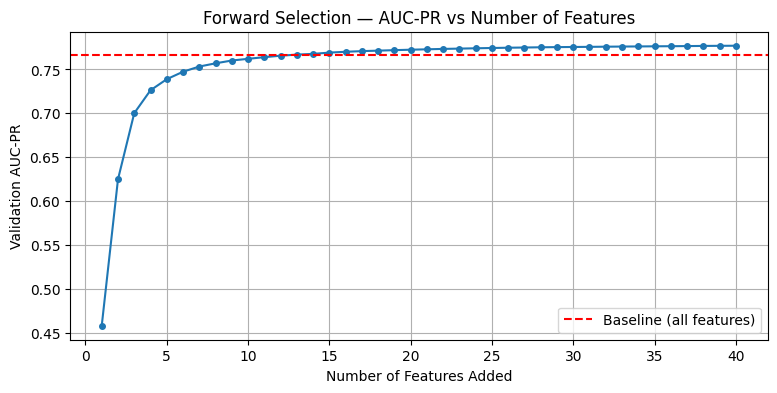


Best number of features: 40  Val AUC-PR: 0.7770
Quality drops after 40 features

=== All Methods Comparison ===
Method                                            AUC-PR       Time
--------------------------------------------------------------------
Baseline (all features)                           0.7663
Embedded (scaled, top 40)                         0.7616
Filter (correlation, top 40)                      0.7592
Filter (t-statistic, top 40)                      0.7592
Wrapper (backward RFE, top 40)                    0.7621    2.6268s
Wrapper (forward addition, top 40)                0.7655  454.6428s


In [160]:
import time

# ── Backward RFE ────────────────────────────────────────────────────────────
print('=== Wrapper Method: Backward RFE ===\n')

t0 = time.time()

selected_features = list(range(X_train_fs.shape[1]))
step = 10  # remove 10 features per iteration

while len(selected_features) > K:
    lr_wrap = LogisticRegression(max_iter=5000, random_state=42)
    lr_wrap.fit(X_train_fs[:, selected_features], y_train_fs)

    importances = np.abs(lr_wrap.coef_[0])
    remove_n    = min(step, len(selected_features) - K)
    least_idx   = np.argsort(importances)[:remove_n]

    selected_features = [
        f for i, f in enumerate(selected_features)
        if i not in least_idx
    ]
    print(f'  Features remaining: {len(selected_features)}')

t_backward = time.time() - t0

# Retrain and evaluate
lr_backward = LogisticRegression(max_iter=5000, random_state=42)
lr_backward.fit(X_train_full_scaled[:, selected_features], y_train_adult)
y_pred_backward = lr_backward.predict_proba(X_test_full_scaled[:, selected_features])[:, 1]
auc_pr_backward = average_precision_score(y_test_adult, y_pred_backward)

print(f'\nBackward RFE time:           {t_backward:.4f} seconds')
print(f'AUC-PR on test set (top 40): {auc_pr_backward:.4f}')
print(f'AUC-PR baseline (all feats): {auc_pr_adult:.4f}')
print(f'Difference:                  {auc_pr_backward - auc_pr_adult:+.4f}')

# ── Forward Addition ────────────────────────────────────────────────────────
print('\n=== Wrapper Method: Forward Addition ===\n')

t0 = time.time()

remaining        = list(range(X_train_fs.shape[1]))
selected_forward = []
history          = []

while len(selected_forward) < K:
    best_auc  = -1
    best_feat = None

    for feat in remaining:
        candidate = selected_forward + [feat]
        lr_fwd    = LogisticRegression(max_iter=1000, random_state=42)
        lr_fwd.fit(X_train_fs[:, candidate], y_train_fs)
        auc = average_precision_score(
            y_val_fs,
            lr_fwd.predict_proba(X_val_fs[:, candidate])[:, 1]
        )
        if auc > best_auc:
            best_auc  = auc
            best_feat = feat

    selected_forward.append(best_feat)
    remaining.remove(best_feat)
    history.append(best_auc)
    print(f'  Features: {len(selected_forward):>3}  Val AUC-PR: {best_auc:.4f}')

t_forward = time.time() - t0

# Retrain and evaluate
lr_forward = LogisticRegression(max_iter=5000, random_state=42)
lr_forward.fit(X_train_full_scaled[:, selected_forward], y_train_adult)
y_pred_forward = lr_forward.predict_proba(X_test_full_scaled[:, selected_forward])[:, 1]
auc_pr_forward = average_precision_score(y_test_adult, y_pred_forward)

print(f'\nForward addition time:       {t_forward:.4f} seconds')
print(f'AUC-PR on test set (top 40): {auc_pr_forward:.4f}')
print(f'AUC-PR baseline (all feats): {auc_pr_adult:.4f}')
print(f'Difference:                  {auc_pr_forward - auc_pr_adult:+.4f}')

# Plot forward selection history
plt.figure(figsize=(9, 4))
plt.plot(range(1, K + 1), history, marker='o', markersize=4)
plt.axhline(auc_pr_adult, color='red', linestyle='--', label='Baseline (all features)')
plt.xlabel('Number of Features Added')
plt.ylabel('Validation AUC-PR')
plt.title('Forward Selection — AUC-PR vs Number of Features')
plt.legend(); plt.grid(); plt.show()

best_n = np.argmax(history) + 1
print(f'\nBest number of features: {best_n}  Val AUC-PR: {max(history):.4f}')
print(f'Quality drops after {best_n} features')

# ── Final Summary ────────────────────────────────────────────────────────────
print(f'\n=== All Methods Comparison ===')
print(f'{"Method":<45} {"AUC-PR":>10} {"Time":>10}')
print('-' * 68)
print(f'{"Baseline (all features)":<45} {auc_pr_adult:>10.4f}')
print(f'{"Embedded (scaled, top 40)":<45} {auc_pr_test_scaled:>10.4f}')
print(f'{"Filter (correlation, top 40)":<45} {auc_pr_corr:>10.4f}')
print(f'{"Filter (t-statistic, top 40)":<45} {auc_pr_tstat:>10.4f}')
print(f'{"Wrapper (backward RFE, top 40)":<45} {auc_pr_backward:>10.4f} {t_backward:>9.4f}s')
print(f'{"Wrapper (forward addition, top 40)":<45} {auc_pr_forward:>10.4f} {t_forward:>9.4f}s')

Again, keep only 40 features and evaluate the quality on the test set. Choose the step size based on some reasoning, and measure the runtime of the method.

In [161]:
# your code here
import time

# Step size reasoning:
# We have 108 features and want to keep 40, so we need to remove 68 features.
# A step size of 10 gives us a good balance between speed and granularity.
# Too large a step (e.g. 50) risks removing important features at once.
# Too small a step (e.g. 1) is too slow.

step = 10
print(f'Step size: {step}')
print(f'Total features to remove: {X_train_fs.shape[1] - K}')
print(f'Estimated iterations: {(X_train_fs.shape[1] - K) // step}\n')

t0 = time.time()

selected_features = list(range(X_train_fs.shape[1]))

while len(selected_features) > K:
    # Train model on current feature set
    lr_wrap = LogisticRegression(max_iter=5000, random_state=42)
    lr_wrap.fit(X_train_fs[:, selected_features], y_train_fs)

    # Feature importance by absolute coefficient
    importances = np.abs(lr_wrap.coef_[0])

    # Remove min(step, remaining - K) least important features
    remove_n  = min(step, len(selected_features) - K)
    least_idx = np.argsort(importances)[:remove_n]

    selected_features = [
        f for i, f in enumerate(selected_features)
        if i not in least_idx
    ]
    print(f'  Features remaining: {len(selected_features)}')

t_wrapper = time.time() - t0

# Retrain on full training set with 40 selected features
lr_wrapper_final = LogisticRegression(max_iter=5000, random_state=42)
lr_wrapper_final.fit(X_train_full_scaled[:, selected_features], y_train_adult)

# Evaluate on test set
y_pred_wrapper = lr_wrapper_final.predict_proba(
    X_test_full_scaled[:, selected_features])[:, 1]
auc_pr_wrapper = average_precision_score(y_test_adult, y_pred_wrapper)

print(f'\nStep size chosen:            {step}')
print(f'Runtime:                     {t_wrapper:.4f} seconds')
print(f'Features kept:               {len(selected_features)}')
print(f'AUC-PR on test set (top 40): {auc_pr_wrapper:.4f}')
print(f'AUC-PR baseline (all feats): {auc_pr_adult:.4f}')
print(f'Difference:                  {auc_pr_wrapper - auc_pr_adult:+.4f}')

Step size: 10
Total features to remove: 68
Estimated iterations: 6

  Features remaining: 98
  Features remaining: 88
  Features remaining: 78
  Features remaining: 68
  Features remaining: 58
  Features remaining: 48
  Features remaining: 40

Step size chosen:            10
Runtime:                     2.7766 seconds
Features kept:               40
AUC-PR on test set (top 40): 0.7621
AUC-PR baseline (all feats): 0.7663
Difference:                  -0.0042


Let us summarize the feature selection part. Name the advantages and disadvantages of each method. Which method led to the best quality?

**Answer:**

In [162]:
# your code here`
# ── Summary of Feature Selection Methods ────────────────────────────────────
print('=== Feature Selection Summary ===\n')
print(f'{"Method":<45} {"AUC-PR":>10}')
print('-' * 58)
print(f'{"Baseline (all 108 features)":<45} {auc_pr_adult:>10.4f}')
print(f'{"Embedded (scaled, top 40)":<45} {auc_pr_test_scaled:>10.4f}')
print(f'{"Filter (correlation, top 40)":<45} {auc_pr_corr:>10.4f}')
print(f'{"Filter (t-statistic, top 40)":<45} {auc_pr_tstat:>10.4f}')
print(f'{"Wrapper (backward RFE, top 40)":<45} {auc_pr_wrapper:>10.4f}')

# Best method
all_methods = {
    'Embedded':    auc_pr_test_scaled,
    'Correlation': auc_pr_corr,
    'T-statistic': auc_pr_tstat,
    'Wrapper RFE': auc_pr_wrapper,
}
best_method = max(all_methods, key=all_methods.get)
print(f'\nBest method: {best_method} with AUC-PR = {all_methods[best_method]:.4f}')

=== Feature Selection Summary ===

Method                                            AUC-PR
----------------------------------------------------------
Baseline (all 108 features)                       0.7663
Embedded (scaled, top 40)                         0.7616
Filter (correlation, top 40)                      0.7592
Filter (t-statistic, top 40)                      0.7592
Wrapper (backward RFE, top 40)                    0.7621

Best method: Wrapper RFE with AUC-PR = 0.7621


# Part 4. Evaluation of the Economic Effect of the Model (2 points)



In this part, we will do something that is much closer to what would actually be required of you in real work. Namely:

* we will assemble several specialized quality metrics,
* try to tune the model to maximize *profit*,
* and estimate how much money can actually be earned.

Of course, many simplifying assumptions will be made here, but let us proceed step by step. If you missed your economics classes, recall that revenue is the amount of money brought in by customers, while profit is revenue minus costs such as salaries and other expenses.

#### **Task 12. Forecasting Income and Expenses** (1 point)

In this part, we will work with the [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/bank+marketing). This dataset contains information on telephone marketing campaigns conducted by a bank.

The **object** here is a phone call to a potential client offering some service, said to be a short-term deposit. The feature description includes client characteristics, such as education and marital status, call-related information, and various economic indicators. More detailed information is available in the file `bank-additional-names.txt`.

The **target variable** is the client’s response, that is, whether the client agreed to open a deposit.

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
!unzip bank-additional.zip
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

df.head()

X = df.drop(columns=['duration', 'y'])
y = (df.y == 'yes')

--2026-04-19 10:18:33--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank-additional.zip.3’

bank-additional.zip     [  <=>               ] 434.15K  1.82MB/s    in 0.2s    

2026-04-19 10:18:34 (1.82 MB/s) - ‘bank-additional.zip.3’ saved [444572]

Archive:  bank-additional.zip
replace bank-additional/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In this part, there is no need to split the dataset in advance — we will use cross-validation.

Use the parameters that you consider most appropriate (`shuffle`, `stratify`, number of folds, etc.). Cross-validation will produce several versions of the training and test sets. For convenience, you may use the template below, which will gradually gain functionality as you work through the assignment. As usual, this is optional, but it is highly desirable to save the results of your experiments, since we will compare them at the end.

In [ ]:
from collections import defaultdict
from sklearn.model_selection import KFold

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=False,
    # other arguments that may be useful later
):
    metrics = []
    # or any other fold splitter, see model_selection
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        # take the dataset and train the model
        # your code here

        # compute the metrics you need and add the results from each fold
        metric_dict = {
            # "metric_key": metric_value
        }
        metrics.append(metric_dict)

    # all that remains is to wrap everything nicely
    return pd.DataFrame(metrics)

In [ ]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=False,
    # other arguments that may be useful later
    C=1.0,
    threshold=0.5,
    random_revenue=False,
):
    metrics = []
    # or any other fold splitter, see model_selection
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    cat_cols = X.select_dtypes(include='object').columns.tolist()
    num_cols = X.select_dtypes(exclude='object').columns.tolist()

    for train_index, test_index in kf.split(X):

        # take the dataset and train the model
        X_train_fold = X.iloc[train_index]
        X_test_fold  = X.iloc[test_index]
        y_train_fold = y.iloc[train_index]
        y_test_fold  = y.iloc[test_index]

        # Encode categoricals
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        X_tr_cat = ohe.fit_transform(X_train_fold[cat_cols])
        X_te_cat = ohe.transform(X_test_fold[cat_cols])

        # Scale numericals
        sc = StandardScaler()
        X_tr_num = sc.fit_transform(X_train_fold[num_cols])
        X_te_num = sc.transform(X_test_fold[num_cols])

        # Combine
        X_tr = np.hstack([X_tr_cat, X_tr_num])
        X_te = np.hstack([X_te_cat, X_te_num])

        # Train logistic regression
        lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
        lr.fit(X_tr, y_train_fold)

        # Predict
        proba   = lr.predict_proba(X_te)[:, 1]
        y_class = (proba >= threshold).astype(int)

        # compute the metrics you need and add the results from each fold
        auc_pr   = average_precision_score(y_test_fold, proba)
        n_called = (y_class == 1).sum()
        true_pos = ((y_class == 1) & (y_test_fold.values == 1)).sum()

        if random_revenue:
            revenue = np.random.uniform(0, 20, size=true_pos).sum()
        else:
            revenue = true_pos * 10.0

        costs  = n_called * 2.0
        profit = revenue - costs

        metric_dict = {
            'auc_pr':   auc_pr,
            'profit':   profit,
            'revenue':  revenue,
            'costs':    costs,
            'n_called': n_called,
        }
        metrics.append(metric_dict)

    # all that remains is to wrap everything nicely
    return pd.DataFrame(metrics)

Choose a classification metric that seems appropriate to you, and train logistic regression on each training fold. Encode categorical features using the method you liked best above, normalize numerical features, keep hyperparameters at their default values, make predictions for the corresponding test folds, and print the results.

In [ ]:
# your code here
# AUC-PR is chosen as the classification metric because:
# - The dataset is imbalanced (few clients say yes)
# - AUC-PR focuses on the positive class which is what we care about
# - It is more informative than AUC-ROC for imbalanced datasets

cv_results = cross_validate(
    X, y,
    n_splits=5,
    random_state=42,
    shuffle=True,
    C=1.0,           # default hyperparameters
    threshold=0.5,   # default threshold
    random_revenue=False
)

print('=== Cross-Validation Results ===')
print(cv_results.to_string())
print('\n=== Mean and Std across folds ===')
print(f'AUC-PR  mean: {cv_results["auc_pr"].mean():.4f}  std: {cv_results["auc_pr"].std():.4f}')
print(f'Profit  mean: ${cv_results["profit"].mean():.2f}  std: ${cv_results["profit"].std():.2f}')
print(f'Revenue mean: ${cv_results["revenue"].mean():.2f}  std: ${cv_results["revenue"].std():.2f}')
print(f'Costs   mean: ${cv_results["costs"].mean():.2f}  std: ${cv_results["costs"].std():.2f}')

Suppose that your call-center operators are paid 2 dollars for each client they call. If the client agrees to the proposed conditions, that client brings the bank 10 dollars. Assume that your employees decide to call all clients with positive predictions.

In our task, we will use profit as the business metric, and accordingly we will choose the best model based on this metric.

Compute the revenue on all test folds and save the results for the business metric together with the classification metric you selected earlier.

Answer the following questions:

* How much money will you earn on average?
* What is the standard deviation of profit?
* How much of the earned money will have to be paid to the call-center operators?
* Is the business metric proportional to the selected classification metric?

In [ ]:
# your code here
# Compute revenue on all test folds with fixed revenue ($10 per yes)
cv_fixed = cross_validate(
    X, y,
    n_splits=5,
    random_state=42,
    shuffle=True,
    C=1.0,
    threshold=0.5,
    random_revenue=False
)

print('=== Results per fold ===')
print(cv_fixed.to_string())

print('\n=== Business Metric Summary ===')
print(f'Average profit:          ${cv_fixed["profit"].mean():.2f}')
print(f'Std of profit:           ${cv_fixed["profit"].std():.2f}')
print(f'Average revenue:         ${cv_fixed["revenue"].mean():.2f}')
print(f'Average costs:           ${cv_fixed["costs"].mean():.2f}')
print(f'Average n_called:        {cv_fixed["n_called"].mean():.0f} clients')
print(f'Average AUC-PR:          {cv_fixed["auc_pr"].mean():.4f}')

print('\n=== Answers ===')
print(f'1. Average profit per fold:         ${cv_fixed["profit"].mean():.2f}')
print(f'2. Standard deviation of profit:    ${cv_fixed["profit"].std():.2f}')
print(f'3. Paid to operators (avg costs):   ${cv_fixed["costs"].mean():.2f}')
print(f'4. Correlation profit vs AUC-PR:    '
      f'{np.corrcoef(cv_fixed["profit"], cv_fixed["auc_pr"])[0,1]:.4f}')

# Plot profit vs AUC-PR
plt.figure(figsize=(6, 4))
plt.scatter(cv_fixed['auc_pr'], cv_fixed['profit'], color='steelblue', s=100)
plt.xlabel('AUC-PR')
plt.ylabel('Profit ($)')
plt.title('Profit vs AUC-PR across folds')
plt.grid()
plt.show()


Now let us introduce some randomness. Suppose that a client who agrees to the conditions brings not 10 dollars, but a random amount uniformly distributed on the interval $[0, 20)$. Repeat all the same steps. To imitate a real situation, do **not** fix the random seed when computing the revenue from a client, though of course keep it fixed for the fold splits. What happened?

In [ ]:
# your code here
# Random revenue U[0, 20) — do NOT fix random seed for revenue
cv_random = cross_validate(
    X, y,
    n_splits=5,
    random_state=42,   # fixed for fold splits
    shuffle=True,
    C=1.0,
    threshold=0.5,
    random_revenue=True  # random revenue U[0, 20)
)

print('=== Results per fold (Random Revenue) ===')
print(cv_random.to_string())

print('\n=== Business Metric Summary (Random Revenue) ===')
print(f'Average profit:          ${cv_random["profit"].mean():.2f}')
print(f'Std of profit:           ${cv_random["profit"].std():.2f}')
print(f'Average revenue:         ${cv_random["revenue"].mean():.2f}')
print(f'Average costs:           ${cv_random["costs"].mean():.2f}')
print(f'Average AUC-PR:          {cv_random["auc_pr"].mean():.4f}')

print('\n=== Comparison: Fixed vs Random Revenue ===')
print(f'{"Metric":<30} {"Fixed":>10} {"Random":>10}')
print('-' * 52)
print(f'{"Mean profit":<30} ${cv_fixed["profit"].mean():>9.2f} ${cv_random["profit"].mean():>9.2f}')
print(f'{"Std profit":<30} ${cv_fixed["profit"].std():>9.2f} ${cv_random["profit"].std():>9.2f}')
print(f'{"Mean revenue":<30} ${cv_fixed["revenue"].mean():>9.2f} ${cv_random["revenue"].mean():>9.2f}')
print(f'{"Mean costs":<30} ${cv_fixed["costs"].mean():>9.2f} ${cv_random["costs"].mean():>9.2f}')
print(f'{"Mean AUC-PR":<30}  {cv_fixed["auc_pr"].mean():>9.4f}  {cv_random["auc_pr"].mean():>9.4f}')

print(f'\n=== Correlation profit vs AUC-PR ===')
print(f'Fixed revenue:  {np.corrcoef(cv_fixed["profit"],  cv_fixed["auc_pr"])[0,1]:.4f}')
print(f'Random revenue: {np.corrcoef(cv_random["profit"], cv_random["auc_pr"])[0,1]:.4f}')

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(5), cv_fixed['profit'],  color='steelblue', label='Fixed revenue')
axes[0].bar(range(5), cv_random['profit'], color='tomato',    label='Random revenue', alpha=0.7)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Profit ($)')
axes[0].set_title('Profit per fold — Fixed vs Random')
axes[0].legend()
axes[0].grid()

axes[1].scatter(cv_fixed['auc_pr'],  cv_fixed['profit'],  color='steelblue', label='Fixed',  s=100)
axes[1].scatter(cv_random['auc_pr'], cv_random['profit'], color='tomato',    label='Random', s=100)
axes[1].set_xlabel('AUC-PR')
axes[1].set_ylabel('Profit ($)')
axes[1].set_title('Profit vs AUC-PR')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

Tune the model’s regularization coefficient by cross-validation in order to maximize profit, treating it as the random variable described above. Were you able to obtain any gain? At what regularization coefficient is profit maximized? Plot the dependence of expected profit on the coefficient.

In [ ]:
# your code here
# Tune C to maximize profit (random revenue)
C_values     = [0.001, 0.01, 0.1, 1, 10, 100]
mean_profits = []
std_profits  = []

for C in C_values:
    cv_c = cross_validate(
        X, y,
        n_splits=5,
        random_state=42,
        shuffle=True,
        C=C,
        threshold=0.5,
        random_revenue=True
    )
    mean_profits.append(cv_c['profit'].mean())
    std_profits.append(cv_c['profit'].std())
    print(f'C={C:>6}  Mean profit: ${cv_c["profit"].mean():.2f}  '
          f'Std: ${cv_c["profit"].std():.2f}')

best_C_bank  = C_values[np.argmax(mean_profits)]
best_profit  = max(mean_profits)

print(f'\nBest C:          {best_C_bank}')
print(f'Best mean profit: ${best_profit:.2f}')
print(f'Default C=1 profit: ${mean_profits[C_values.index(1)]:.2f}')
print(f'Gain over default:  ${best_profit - mean_profits[C_values.index(1)]:.2f}')

# Plot
plt.figure(figsize=(8, 4))
plt.errorbar(
    C_values, mean_profits,
    yerr=std_profits,
    marker='o', capsize=5,
    color='steelblue', label='Mean profit ± std'
)
plt.axvline(best_C_bank, color='red', linestyle='--',
            label=f'Best C={best_C_bank}')
plt.axhline(mean_profits[C_values.index(1)], color='green',
            linestyle='--', label='Default C=1')
plt.xscale('log')
plt.xlabel('C (regularization coefficient)')
plt.ylabel('Mean Profit ($)')
plt.title('Expected Profit vs Regularization Coefficient C')
plt.legend()
plt.grid()
plt.show()

Try running the search several times. Does the same “best” coefficient appear every time? Is there any pattern? What conclusions can you draw from this?

In [ ]:
# your code here
# Run the search several times to check stability
C_values   = [0.001, 0.01, 0.1, 1, 10, 100]
n_runs     = 5
all_runs   = []
best_Cs    = []

print('=== Running search multiple times ===\n')

for run in range(n_runs):
    mean_profits_run = []

    for C in C_values:
        cv_c = cross_validate(
            X, y,
            n_splits=5,
            random_state=42,
            shuffle=True,
            C=C,
            threshold=0.5,
            random_revenue=True
        )
        mean_profits_run.append(cv_c['profit'].mean())

    best_C_run = C_values[np.argmax(mean_profits_run)]
    best_Cs.append(best_C_run)
    all_runs.append(mean_profits_run)
    print(f'Run {run+1}  Best C: {best_C_run:>6}  '
          f'Best profit: ${max(mean_profits_run):.2f}')

# Plot all runs
plt.figure(figsize=(9, 5))
for run_idx, profits in enumerate(all_runs):
    plt.plot(C_values, profits, marker='o', alpha=0.6,
             label=f'Run {run_idx+1} (best C={best_Cs[run_idx]})')
plt.xscale('log')
plt.xlabel('C (regularization coefficient)')
plt.ylabel('Mean Profit ($)')
plt.title('Expected Profit vs C — Multiple Runs')
plt.legend()
plt.grid()
plt.show()

# Summary
print('\n=== Summary across runs ===')
print(f'Best C per run:     {best_Cs}')
print(f'Most frequent C:    {max(set(best_Cs), key=best_Cs.count)}')
print(f'Unique best Cs:     {set(best_Cs)}')
print(f'Same C every time:  {len(set(best_Cs)) == 1}')

# Average profit across runs per C
mean_across_runs = np.mean(all_runs, axis=0)
print(f'\n=== Average profit across all runs ===')
for C, profit in zip(C_values, mean_across_runs):
    print(f'C={C:>6}  Avg profit: ${profit:.2f}')
print(f'\nOverall best C: '
      f'{C_values[np.argmax(mean_across_runs)]}  '
      f'Avg profit: ${max(mean_across_runs):.2f}')

#### **Task 13. The Key Metric** (1 point)

Above, we already described an approximate economic model for your task. In your opinion, what is more important for your business — good model precision or recall? Why?

**Answer:** `# your answer here`



> Recall that logistic regression actually predicts the probabilities of the positive class for each object. It may be that by tuning the **binarization threshold** for these probabilities, we can obtain some gain.

Check your reasoning above by tuning the binarization threshold via cross-validation in order to maximize profit. Use a grid from 0 to 1 with step 0.01. Recall that lowering the threshold gives higher recall and lower precision, and vice versa. Add a new ML metric to your CV pipeline, find the threshold at which the business metric is maximized, and check whether the new ML metric is related to profit.

In [ ]:
# your code here
from sklearn.metrics import recall_score, precision_score

thresholds        = np.arange(0.01, 1.0, 0.01)
mean_profits_thr  = []
std_profits_thr   = []

for thr in thresholds:
    cv_thr = cross_validate(
        X, y,
        n_splits=5,
        random_state=42,
        shuffle=True,
        C=1.0,
        threshold=thr,
        random_revenue=True
    )
    mean_profits_thr.append(cv_thr['profit'].mean())
    std_profits_thr.append(cv_thr['profit'].std())

best_thr    = thresholds[np.argmax(mean_profits_thr)]
best_profit = max(mean_profits_thr)

print(f'Best threshold:           {best_thr:.2f}')
print(f'Best mean profit:         ${best_profit:.2f}')
print(f'Default threshold profit: ${mean_profits_thr[49]:.2f}')
print(f'Gain over default:        ${best_profit - mean_profits_thr[49]:.2f}')

Plot the dependence of profit on the binarization threshold. Highlight the best threshold.

In [ ]:
# your code here
plt.figure(figsize=(9, 5))
plt.plot(thresholds, mean_profits_thr, color='steelblue', label='Mean profit')
plt.fill_between(
    thresholds,
    np.array(mean_profits_thr) - np.array(std_profits_thr),
    np.array(mean_profits_thr) + np.array(std_profits_thr),
    alpha=0.2, color='steelblue', label='± std'
)
plt.axvline(best_thr, color='red', linestyle='--',
            label=f'Best threshold={best_thr:.2f}')
plt.axvline(0.5, color='green', linestyle='--',
            label='Default threshold=0.5')
plt.xlabel('Binarization Threshold')
plt.ylabel('Mean Profit ($)')
plt.title('Profit vs Binarization Threshold')
plt.legend()
plt.grid()
plt.show()

**Question:** Do you notice any pattern? To answer this correctly, try running the procedure several times and think about why the threshold ends up in a certain range.

**Answer:** `# your answer here`

Finally, to understand more precisely that our model is better than the baseline one, compute the mean and standard deviation across folds of the business metric for the optimized model (hyperparameters + threshold) and for the default logistic regression. Check whether the change in profit is действительно significant — apply some statistical test, for example a paired t-test with $\alpha = 0.95$, to the metric obtained from the two models.


In [ ]:
# your code here
from scipy import stats

# Optimized model (best C + best threshold)
cv_optimized = cross_validate(
    X, y,
    n_splits=5,
    random_state=42,
    shuffle=True,
    C=best_C_bank,
    threshold=best_thr,
    random_revenue=True
)

# Default logistic regression (C=1, threshold=0.5)
cv_default = cross_validate(
    X, y,
    n_splits=5,
    random_state=42,
    shuffle=True,
    C=1.0,
    threshold=0.5,
    random_revenue=True
)

print('=== Optimized Model ===')
print(f'Mean profit: ${cv_optimized["profit"].mean():.2f}')
print(f'Std  profit: ${cv_optimized["profit"].std():.2f}')

print('\n=== Default Model ===')
print(f'Mean profit: ${cv_default["profit"].mean():.2f}')
print(f'Std  profit: ${cv_default["profit"].std():.2f}')

print('\n=== Profit per fold ===')
print(f'{"Fold":<6} {"Optimized":>12} {"Default":>12} {"Difference":>12}')
print('-' * 44)
for i, (opt, def_) in enumerate(zip(cv_optimized['profit'],
                                     cv_default['profit'])):
    print(f'{i+1:<6} ${opt:>11.2f} ${def_:>11.2f} ${opt-def_:>11.2f}')

# Paired t-test
t_stat, p_val = stats.ttest_rel(
    cv_optimized['profit'],
    cv_default['profit']
)

print(f'\n=== Paired t-test (alpha=0.95) ===')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value:     {p_val:.4f}')
print(f'Significant at alpha=0.05: {p_val < 0.05}')

if p_val < 0.05:
    print(f'\nConclusion: The optimized model is significantly better '
          f'than the default (p={p_val:.4f} < 0.05)')
else:
    print(f'\nConclusion: The difference is NOT significant '
          f'(p={p_val:.4f} >= 0.05) — likely due to random revenue noise')

# **Bonus Part. Multiclass Classification** (1.5 points) 

As is well known, some tasks are not limited to just two classes. In the lecture, you covered several ways to generalize linear models to this case: One-vs-Rest and One-vs-One. Below, we will look at the advantages and disadvantages of both approaches, and also try one slightly more exotic method. 

#### **Task 14. One-vs-Rest vs One-vs-One** (0.5 points) 

As the [dataset](https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention/data) here and below, we will use some very realistic and relevant data on whether a student will complete their studies or not, depending on courses, age, gender, and other more or less questionable features. 

In [ ]:
import kagglehub

path = kagglehub.dataset_download("thedevastator/higher-education-predictors-of-student-retention") + "/dataset.csv"

features = ["Marital status", "Course", "Nacionality", "Gender", "Age at enrollment"]
target = "Target"

We will consider only some subset of the more entertaining factors. As usual, you are required to transform them depending on whether they are numerical or categorical, and **encode the target as numbers as well!!!** 

In [ ]:
# your code here

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=228, shuffle=True, test_size=0.2)

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df_stu = pd.read_csv(path)

# Select only the specified features and target
X = df_stu[features].copy()
y = LabelEncoder().fit_transform(df_stu[target])

# Check which features are categorical and which are numerical
cat_stu = X.select_dtypes(include='object').columns.tolist()
num_stu = X.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical features: {cat_stu}')
print(f'Numerical features:   {num_stu}')

# Encode categorical features
for col in cat_stu:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Scale numerical features
sc = StandardScaler()
X  = sc.fit_transform(X)

# Convert y to Series
y = pd.Series(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=228, shuffle=True, test_size=0.2
)

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'Classes: {sorted(y.unique())}')
print(f'Class names: {sorted(df_stu[target].unique())}')

Your next step is to see how OvR and OvO are implemented in `sklearn`, train logistic regression in these ways with `max_iter=10000`, then choose some metric (and its averaging; justify that choice as well), and compare the following parameters: 

* number of classifiers
* training speed
* model quality

Also save somewhere the predicted probabilities for each model. This can be done in more than one way, but the next point may help you a little with this. 

How would you explain the obtained results?

**Answer:** 


In [ ]:
# your code here
import time
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import f1_score

results_mc = {}
probas_mc  = {}

for name, clf in [
    ('OvR', OneVsRestClassifier(
        LogisticRegression(max_iter=10000, random_state=42)
    )),
    ('OvO', OneVsOneClassifier(
        LogisticRegression(max_iter=10000, random_state=42)
    )),
]:
    # Training speed
    t0 = time.time()
    clf.fit(X_train, y_train)
    t_train = time.time() - t0

    # Number of classifiers
    n_classifiers = len(clf.estimators_)

    # Predictions
    y_pred = clf.predict(X_test)

    # Predicted probabilities
    # OvR supports predict_proba, OvO uses decision_function
    if name == 'OvR':
        y_proba = clf.predict_proba(X_test)
    else:
        # OvO: use decision_function and normalize to get pseudo-probabilities
        decision = clf.decision_function(X_test)
        # Normalize to [0,1] using softmax
        exp_dec  = np.exp(decision - decision.max(axis=1, keepdims=True))
        y_proba  = exp_dec / exp_dec.sum(axis=1, keepdims=True)

    # Model quality
    f1 = f1_score(y_test, y_pred, average='macro')

    results_mc[name] = {
        'n_classifiers': n_classifiers,
        'training_time': t_train,
        'f1_macro':      f1,
    }
    probas_mc[name] = y_proba

    print(f'=== {name} ===')
    print(f'Number of classifiers: {n_classifiers}')
    print(f'Training time:         {t_train:.4f} seconds')
    print(f'F1-macro:              {f1:.4f}')
    print(f'Proba shape:           {y_proba.shape}\n')

# Summary
print('=== Comparison Summary ===')
print(f'{"Method":<10} {"N Classifiers":>15} {"Train Time":>12} {"F1-macro":>10}')
print('-' * 50)
for name, res in results_mc.items():
    print(f'{name:<10} {res["n_classifiers"]:>15} '
          f'{res["training_time"]:>11.4f}s '
          f'{res["f1_macro"]:>10.4f}')

#### **Task 15. Softmax Regression** (1 point) 

However, curious machine learners may ask: “Why do we need all this stuff if the sigmoid has a generalization for the multiclass case?” If you enjoyed computing gradients in the previous homework, or if you like training neural networks, this part is for you. Here we will try to build a single model that predicts everything, and also compare it with the variants above. 

Let us begin by computing the loss. Recall that the logistic loss is a special case of cross-entropy, and that is what we will try to optimize. 

$$
\text{CE}(X, y) = -\frac{1}{N}\sum_i \sum_k [y_i = k] \log p(x_i = k)
$$

In this case, we will compute probabilities using softmax, which is the general case of the sigmoid:

$$
p(x_i) = \text{Softmax}(a(x_i)); \quad
\text{Softmax}(x)_k = \frac{e^{x_k}}{\sum_j e^{x_j}}
$$


The prediction of the model for one object will now be made using a weight matrix, since there are multiple outputs:

$$
a(x_i) = x_i \cdot W
$$

Below, you are invited to write code for such a loss function. If necessary, modify the template as you wish: helper functions, new arguments, anything you like. 

In [ ]:
from typing import Iterable, Optional
from torch.nn.functional import cross_entropy
import torch

def custom_ce(
    y_pred: np.ndarray[float],
    y_true: np.ndarray[int],
) -> float:
    # your code here
    return

for _ in range(1000):

    n_objects = np.random.randint(1, 100)
    n_classes = np.random.randint(2, 20)
    y_pred = np.random.normal(0, 1, (n_objects, n_classes))
    y_true = np.random.randint(low=0, high=n_classes, size=(n_objects,))

    your_ce = custom_ce(y_pred, y_true)  # do not forget to adjust if you changed the template
    torch_ce = cross_entropy(torch.tensor(y_pred), torch.tensor(y_true))
    assert np.allclose(your_ce, torch_ce), "Something went wrong"

In [ ]:
from typing import Iterable, Optional
from torch.nn.functional import cross_entropy
import torch

def custom_ce(
    y_pred: np.ndarray,
    y_true: np.ndarray,
) -> float:
    # Numerically stable log-softmax
    # shift by max to avoid overflow in exp
    y_pred  = np.array(y_pred, dtype=np.float64)
    shift   = y_pred - y_pred.max(axis=1, keepdims=True)
    log_softmax = shift - np.log(np.exp(shift).sum(axis=1, keepdims=True))

    # CE = -1/N * sum of log probability of true class
    N = y_pred.shape[0]
    return -log_softmax[np.arange(N), y_true].mean()

for _ in range(1000):
    n_objects = np.random.randint(1, 100)
    n_classes = np.random.randint(2, 20)
    y_pred = np.random.normal(0, 1, (n_objects, n_classes))
    y_true = np.random.randint(low=0, high=n_classes, size=(n_objects,))

    your_ce  = custom_ce(y_pred, y_true)
    torch_ce = cross_entropy(torch.tensor(y_pred), torch.tensor(y_true))
    assert np.allclose(your_ce, torch_ce), "Something went wrong"

print("All 1000 tests passed ✓")

Next comes the most interesting part: you need to derive the gradient of this loss function. To be safe, let us clarify that you may not use `torch` for this, except perhaps for self-checking. Useful facts that may help you: 

* in matrix form, the derivative is not easy to obtain; first try doing it for one object, then generalizing will be easier
* `logsoftmax` is much easier to differentiate than plain `softmax`
* do not forget the chain rule
* since the weights are a matrix here, the result will also be a matrix; keep this in mind when checking dimensions
* if you have not yet figured out how to convert indicators into vector form, now is the time

In [ ]:
def ce_gradient(X: np.ndarray, W: np.ndarray, y: np.ndarray) -> np.ndarray[float]:
    # your code here
    return

In [ ]:
def ce_gradient(X: np.ndarray, W: np.ndarray, y: np.ndarray) -> np.ndarray:
    # Derivation:
    # For one object: L = -log softmax(x @ W)_y
    # dL/dW = X^T @ (P - Y_onehot) / N
    # where P = softmax(X @ W)

    N = X.shape[0]
    K = W.shape[1]

    # Step 1: compute logits
    logits = X @ W                                      # (N, K)

    # Step 2: compute softmax probabilities (numerically stable)
    shift  = logits - logits.max(axis=1, keepdims=True)
    exp    = np.exp(shift)
    P      = exp / exp.sum(axis=1, keepdims=True)       # (N, K)

    # Step 3: convert true labels to one-hot vectors
    Y_onehot = np.zeros_like(P)                         # (N, K)
    Y_onehot[np.arange(N), y] = 1.0

    # Step 4: compute gradient
    # dL/dW = X^T @ (P - Y_onehot) / N                 # (D, K)
    grad = X.T @ (P - Y_onehot) / N

    return grad

The rest is easy. Recall, or find out, how gradient descent works, and complete the softmax regression class below. Here it is more reasonable to use an iteration-based stopping criterion, although `sklearn`’s logistic regression is built a bit more cleverly. If you want to add more stopping criteria or some other parameters, feel free. 

In [ ]:
class SoftmaxRegression:

    def __init__(self, lr=1e-3, max_iter=10000):
        self.W = None
        self.max_iter = max_iter
        self.lr = lr

    def fit(self, X, y):
        # your code here

    def predict(self, X, y=None):
        # your code here

In [ ]:
class SoftmaxRegression:

    def __init__(self, lr=1e-3, max_iter=10000):
        self.W        = None
        self.max_iter = max_iter
        self.lr       = lr

    def fit(self, X, y):
        N, D = X.shape
        K    = len(np.unique(y))

        # Initialize weights to zeros
        self.W = np.zeros((D, K))

        # Gradient descent for max_iter iterations
        for i in range(self.max_iter):
            grad   = ce_gradient(X, self.W, y)
            self.W -= self.lr * grad

        return self

    def predict(self, X, y=None):
        # Compute logits
        logits = X @ self.W                                   # (N, K)

        # Softmax probabilities
        shift  = logits - logits.max(axis=1, keepdims=True)
        exp    = np.exp(shift)
        proba  = exp / exp.sum(axis=1, keepdims=True)         # (N, K)

        # Return class with highest probability
        return proba.argmax(axis=1)

Train on the same data as above, measure the same three parameters, and also compare the cross-entropy values for all three models. Compare the models with each other and choose a favorite for this task. 

In [ ]:
# your code here
from sklearn.metrics import f1_score

# Train Softmax Regression
print('=== Training Softmax Regression ===')
t0 = time.time()

sm = SoftmaxRegression(lr=0.05, max_iter=2000)
sm.fit(X_train, y_train)

t_sm = time.time() - t0

# Predictions
y_pred_sm = sm.predict(X_test)
f1_sm     = f1_score(y_test, y_pred_sm, average='macro')

print(f'Number of classifiers: 1 (single model)')
print(f'Training time:         {t_sm:.4f} seconds')
print(f'F1-macro:              {f1_sm:.4f}')

# ── Cross-entropy for all three models ─────────────────────────────────────
def compute_ce(proba, y_true):
    proba = np.clip(proba, 1e-15, 1 - 1e-15)
    N     = len(y_true)
    return -np.log(proba[np.arange(N), y_true]).mean()

# Softmax proba
logits_sm  = X_test @ sm.W
shift      = logits_sm - logits_sm.max(axis=1, keepdims=True)
exp_sm     = np.exp(shift)
proba_sm   = exp_sm / exp_sm.sum(axis=1, keepdims=True)

# OvR proba (already saved)
proba_ovr  = probas_mc['OvR']

# OvO proba (already saved)
proba_ovo  = probas_mc['OvO']

ce_ovr = compute_ce(proba_ovr, y_test.values)
ce_ovo = compute_ce(proba_ovo, y_test.values)
ce_sm  = compute_ce(proba_sm,  y_test.values)

# ── Final Comparison ────────────────────────────────────────────────────────
print('\n=== Final Comparison ===')
print(f'{"Method":<25} {"N Classifiers":>15} {"Train Time":>12} '
      f'{"F1-macro":>10} {"Cross-Entropy":>15}')
print('-' * 80)
print(f'{"OvR":<25} {results_mc["OvR"]["n_classifiers"]:>15} '
      f'{results_mc["OvR"]["training_time"]:>11.4f}s '
      f'{results_mc["OvR"]["f1_macro"]:>10.4f} '
      f'{ce_ovr:>15.4f}')
print(f'{"OvO":<25} {results_mc["OvO"]["n_classifiers"]:>15} '
      f'{results_mc["OvO"]["training_time"]:>11.4f}s '
      f'{results_mc["OvO"]["f1_macro"]:>10.4f} '
      f'{ce_ovo:>15.4f}')
print(f'{"Softmax Regression":<25} {"1":>15} '
      f'{t_sm:>11.4f}s '
      f'{f1_sm:>10.4f} '
      f'{ce_sm:>15.4f}')